In [85]:
#Load libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import sklearn as sk
import sklearn.preprocessing as skprep

#Image saving
!pip install selenium #To save maps from folium
import selenium
import io
from PIL import Image

#For probability maps
import plotly.express as px

In [86]:
#Connect drive to Collab

from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [87]:
import os
# List files in the directory
file_list = os.listdir('/content/drive/MyDrive/PhD data analysis/Paper1/')
print(file_list)

['Data_exploration_visualization.ipynb', 'Fire_NIS.csv', 'Water_NIS.csv', 'Fire_TAUW.csv', 'Water_TAUW.csv', 'Raw datasets', 'preprocessed_df.csv', 'LSTM.ipynb', '.ipynb_checkpoints', 'x3.csv', 'x4.csv', 'x5.csv', 'df_pred.csv', 'Copy of LSTM_2.ipynb', 'spatial_dist_30000.csv', 'spatial_dist_10000.csv', 'Models', 'GCNLSTM_1616.csv', 'spatial_dist_suburban.csv', 'spatial_dist_ams_ut.csv', 'spatial_dist_dh_rot.csv', 'spatial_dist_outlier.csv', 'spatial_dist_limburg.csv', 'test_gcn5.csv', 'test_gcn4.csv', 'test_gcn3.csv', 'test_gcn2.csv', 'gcnblstm_training_log3.csv', 'test3_gcnblstm.csv', 'gcnblstm_training_log4.csv', 'test4_gcnblstm.csv', 'gcnblstm_training_log5.csv', 'gat_training_log1.csv', 'test1_gat.csv', 'test3_gat.csv', 'gat_training_log3.csv', 'gat_training_log4.csv', 'test2_gat.csv', 'test4_gat.csv', 'gat_training_log5.csv', 'test5_gat.csv', 'gcnblstm_training_log2.csv', 'test2_gcnblstm.csv', 'gcnblstm_training_log1.csv', 'test1_gcnblstm.csv', 'test5_gcnblstm.csv', 'test5_gcnbls

In [88]:
#Load dataset

df = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/preprocessed_df.csv")  #Preprocessing data - left at 'Overig' incident type to redo the labels
df.head()

,OBJECTID,dataset,start_date,start_time,end_date,end_time,incident_duration,incident_type,incident_description,traffic_jam,...,sum_prec (1h),max_prec (5min),max_temp,round_max_temp,low_veg_%,mid_high_veg_%,misc_%,pavement_%,water_%,total_acreage_%
0,1,UDLS,1/21/2014,12:46:46,1/21/2014,13:44:12,00:57:25,Overig,modder op oprit,NaN,...,0.0,0.0,5.753218,6,35.0,NaN,1.0,33.0,3.0,72
1,2,UDLS,1/27/2014,11:52:00,1/27/2014,12:48:00,00:56:00,Wateroverlast,wateroverlast geldrop,NaN,...,0.0,0.0,5.988402,6,40.0,4.0,6.0,34.0,1.0,85
2,3,UDLS,2-6-2014,08:35:41,2-7-2014,15:38:36,07:02:54,Schade aan infra,uitspoeling in de mb,NaN,...,0.0,0.0,9.551981,10,64.0,NaN,0.0,30.0,2.0,96
3,4,UDLS,3-5-2014,00:56:27,3-5-2014,04:07:14,03:10:47,Zichtbaarheid,mist everdingen - deil,NaN,...,0.0,0.0,12.243471,12,41.0,17.0,1.0,26.0,7.0,92
4,5,UDLS,3/14/2014,07:00:14,3/14/2014,12:10:04,05:09:50,Zichtbaarheid,gesloten sps i.v.m. mist,NaN,...,0.0,0.0,11.787109,12,61.0,9.0,NaN,24.0,6.0,100


In [89]:
#Preprocessing step 1 (Handling NAs)

#Check missing values
print('Columns with missing values:', df.isnull().any())
print('Observations of original df:', len(df))

#Remove observations with a missing end time/end date
df_1 = df.dropna(subset=['end_date', 'end_time', 'incident_type'])

print('--------------------------')

#Check missing values
print('After removal:', df_1.isnull().any())
print('Observations of cleaned df:', len(df_1))

#Replacing all NAs in traffic and areal variables with 0
df_1 = df_1.fillna(0)

print('--------------------------')

#Check missing values again
print('After filling NAs with 0:', df_1.isnull().any())

Columns with missing values: OBJECTID                False
dataset                 False
start_date              False
start_time              False
end_date                 True
end_time                 True
incident_duration       False
incident_type            True
incident_description    False
traffic_jam              True
road_level              False
lon                     False
lat                     False
sum_prec (1h)           False
max_prec (5min)         False
max_temp                False
round_max_temp          False
low_veg_%                True
mid_high_veg_%           True
misc_%                   True
pavement_%               True
water_%                  True
total_acreage_%         False
dtype: bool
Observations of original df: 7591
--------------------------
After removal: OBJECTID                False
dataset                 False
start_date              False
start_time              False
end_date                False
end_time                False
incident_dura

In [90]:
df_1['incident_type'].unique()

array(['Overig', 'Wateroverlast', 'Schade aan infra', 'Zichtbaarheid',
       'Brand', 'Gladheid', 'Voorwerp', 'Ongeval', 'Gladheidsbestrijding',
       'Storing', 'Invalid - Gladheidsbestrijding', 'Onbekend',
       'Weergerelateerd wegprobleem'], dtype=object)

In [91]:
#Leave out some labels from incident_type

filtered_df = df_1[df_1['incident_type'].isin(['Brand', 'Gladheid',
       'Schade aan infra', 'Wateroverlast', 'Onbekend', 'Overig'])] #'Onbekend', 'Overig'
print(filtered_df)

      OBJECTID       dataset start_date start_time   end_date  end_time  \
0            1          UDLS  1/21/2014   12:46:46  1/21/2014  13:44:12   
1            2          UDLS  1/27/2014   11:52:00  1/27/2014  12:48:00   
2            3          UDLS   2-6-2014   08:35:41   2-7-2014  15:38:36   
5          830          UDLS  2/28/2018   14:54:58  2/28/2018  15:08:49   
6            7          UDLS  4/24/2014   19:50:36  4/25/2014  14:22:17   
...        ...           ...        ...        ...        ...       ...   
7567      5445          UDLS  7/24/2019   10:15:06  7/24/2019  13:47:34   
7568      5452          UDLS  7/25/2019   14:19:02  7/25/2019  16:05:04   
7569      5442          UDLS  7/25/2019   12:21:45  7/25/2019  12:32:45   
7570      5446          UDLS  7/25/2019   12:35:06  7/25/2019  12:40:32   
7571      7338  Dexter files  7/25/2019   14:26:00  7/25/2019  14:57:13   

     incident_duration     incident_type     incident_description  \
0             00:57:25        

In [92]:
#Translate incident labels from Dutch to English

#'Brand', 'Gladheid', 'Schade aan infra', 'Wateroverlast','Zichtbaarheid', 'Onbekend', 'Overig'
#Roadside fire, Slippery pavement, Infrastructure damage, Road ponding, Poor visbility, Unknown, Miscellaneous
filtered_df = filtered_df.replace({'incident_type': {'Brand': 'Roadside fire',
                                                     'Gladheid': 'Slippery pavement', #'Slippery pavement', (Reduce the amount of classes to 3)
                                                     'Schade aan infra': 'Infrastructure damage',#Infrastructure damage',
                                                     'Wateroverlast': 'Road ponding',
                                         #            'Zichtbaarheid':'Poor visbility',
                                                     'Onbekend':'Other',
                                                     'Overig':'Other'}})

In [93]:
filtered_df.shape

(4658, 23)

In [94]:
incidents_all = filtered_df['incident_type'].value_counts()
print(incidents_all)
print(len(filtered_df['incident_type']))

incident_type
Road ponding             2129
Roadside fire            1095
Infrastructure damage     769
Other                     371
Slippery pavement         294
Name: count, dtype: int64
4658


In [95]:
#Preprocessing step 2 - Dropping variables, date_time transformation


#Dropping unnecessary columns and all the temporal columns (Incident type to be preprocessed and added later)
df1 = filtered_df.drop(columns=['OBJECTID',
                       'dataset',
                       'incident_description',
                       'traffic_jam',
                      # 'lat',
                     #  'lon',
                       'round_max_temp',
                       'total_acreage_%'])


#Removing missing values
#print('Columns with missing values:', df.isnull().any())

#Extracting all temporal variables and converting these into datetime[ns64] data
#The temporal information is added to the train, validation, and test datasets later

df1['start_date'] = pd.to_datetime(df1['start_date'], format='mixed', dayfirst=True)
df1['end_date'] = pd.to_datetime(df1['end_date'], format='mixed', dayfirst=True)
df1['incident_duration'] = pd.to_datetime(df1['incident_duration'], format='%H:%M:%S')
df1['start_time'] = pd.to_datetime(df1['start_time'], format='%H:%M:%S')
df1['end_time'] = pd.to_datetime(df1['end_time'], format='%H:%M:%S')

#Label encoding the target variable:

#Defining the encoder
label_enc1 = skprep.LabelEncoder()
label_enc2 = skprep.LabelEncoder()
label_enc1.fit(df1['incident_type'])
label_enc2.fit(df1['road_level'])

#Transforming the target variable
df1['incident_type'] = label_enc1.transform(df1['incident_type'])
df1['road_level'] = label_enc2.transform(df1['road_level'])

df1.head()
df1.dtypes

,0
start_date,datetime64[ns]
start_time,datetime64[ns]
end_date,datetime64[ns]
end_time,datetime64[ns]
incident_duration,datetime64[ns]
incident_type,int64
road_level,int64
lon,float64
lat,float64
sum_prec (1h),float64


In [96]:
#Mapping of labels

label_enc1_mapping = dict(zip(label_enc1.classes_, label_enc1.transform(label_enc1.classes_)))
print(label_enc1_mapping)
label_enc2_mapping = dict(zip(label_enc2.classes_, label_enc2.transform(label_enc2.classes_)))
print(label_enc2_mapping)

{'Infrastructure damage': np.int64(0), 'Other': np.int64(1), 'Road ponding': np.int64(2), 'Roadside fire': np.int64(3), 'Slippery pavement': np.int64(4)}
{'maaiveld': np.int64(0), 'overbrugging': np.int64(1), 'tunneldeel': np.int64(2)}


In [97]:
label_enc1.classes_

array(['Infrastructure damage', 'Other', 'Road ponding', 'Roadside fire',
       'Slippery pavement'], dtype=object)

Barplot URCs over time

In [98]:
df1[100:105]

,start_date,start_time,end_date,end_time,incident_duration,incident_type,road_level,lon,lat,sum_prec (1h),max_prec (5min),max_temp,low_veg_%,mid_high_veg_%,misc_%,pavement_%,water_%
183,2014-12-25,1900-01-01 12:01:53,2014-12-25,1900-01-01 13:10:43,1900-01-01 01:08:50,3,0,5.617599,51.750899,0.12,0.07,7.262763,27.0,3.0,0.0,16.0,2.0
184,2016-12-19,1900-01-01 15:25:06,2016-12-19,1900-01-01 15:34:57,1900-01-01 00:09:51,3,0,4.927456,51.763942,0.00,0.00,7.318756,65.0,0.0,0.0,18.0,3.0
187,2018-06-18,1900-01-01 11:20:11,2018-06-19,1900-01-01 06:21:57,1900-01-01 19:01:46,2,0,5.200831,52.206899,0.04,0.04,19.221966,29.0,18.0,1.0,31.0,0.0
188,2021-09-03,1900-01-01 13:20:10,2021-09-03,1900-01-01 13:30:27,1900-01-01 00:10:17,3,0,4.991632,51.924398,0.00,0.00,7.501097,19.0,6.0,1.0,15.0,2.0
189,2020-03-29,1900-01-01 14:46:25,2020-03-29,1900-01-01 14:58:27,1900-01-01 00:12:02,3,0,5.513456,51.737877,0.00,0.00,7.529711,47.0,1.0,1.0,28.0,1.0


In [99]:
#Convert to geodataframes
df_geo = gpd.GeoDataFrame(df1, geometry=gpd.points_from_xy(df1.lat, df1.lon), crs="EPSG:28992")

df_geo[100:105]

,start_date,start_time,end_date,end_time,incident_duration,incident_type,road_level,lon,lat,sum_prec (1h),max_prec (5min),max_temp,low_veg_%,mid_high_veg_%,misc_%,pavement_%,water_%,geometry
183,2014-12-25,1900-01-01 12:01:53,2014-12-25,1900-01-01 13:10:43,1900-01-01 01:08:50,3,0,5.617599,51.750899,0.12,0.07,7.262763,27.0,3.0,0.0,16.0,2.0,POINT (51.751 5.618)
184,2016-12-19,1900-01-01 15:25:06,2016-12-19,1900-01-01 15:34:57,1900-01-01 00:09:51,3,0,4.927456,51.763942,0.00,0.00,7.318756,65.0,0.0,0.0,18.0,3.0,POINT (51.764 4.927)
187,2018-06-18,1900-01-01 11:20:11,2018-06-19,1900-01-01 06:21:57,1900-01-01 19:01:46,2,0,5.200831,52.206899,0.04,0.04,19.221966,29.0,18.0,1.0,31.0,0.0,POINT (52.207 5.201)
188,2021-09-03,1900-01-01 13:20:10,2021-09-03,1900-01-01 13:30:27,1900-01-01 00:10:17,3,0,4.991632,51.924398,0.00,0.00,7.501097,19.0,6.0,1.0,15.0,2.0,POINT (51.924 4.992)
189,2020-03-29,1900-01-01 14:46:25,2020-03-29,1900-01-01 14:58:27,1900-01-01 00:12:02,3,0,5.513456,51.737877,0.00,0.00,7.529711,47.0,1.0,1.0,28.0,1.0,POINT (51.738 5.513)


In [100]:
#Distributions of URC in entire dataset

print("URC distribution aggregated over time:", df_geo['incident_type'].value_counts())

URC distribution aggregated over time: incident_type
2    2129
3    1095
0     769
1     371
4     294
Name: count, dtype: int64


In [101]:
#Set index to date

df1 = df_geo.sort_values(['start_date'], ascending=[True])
df1 = df_geo.set_index('start_date')
print(df1.head(3))

                    start_time   end_date            end_time  \
start_date                                                      
2014-01-21 1900-01-01 12:46:46 2014-01-21 1900-01-01 13:44:12   
2014-01-27 1900-01-01 11:52:00 2014-01-27 1900-01-01 12:48:00   
2014-06-02 1900-01-01 08:35:41 2014-07-02 1900-01-01 15:38:36   

             incident_duration  incident_type  road_level       lon  \
start_date                                                            
2014-01-21 1900-01-01 00:57:25              1           0  5.186706   
2014-01-27 1900-01-01 00:56:00              2           1  5.254379   
2014-06-02 1900-01-01 07:02:54              0           0  5.146372   

                  lat  sum_prec (1h)  max_prec (5min)  max_temp  low_veg_%  \
start_date                                                                   
2014-01-21  51.903114            0.0              0.0  5.753218       35.0   
2014-01-27  51.829996            0.0              0.0  5.988402       40.0   
2014-0

In [102]:
#Split data according to year

df_2014 = df1.loc['2014']
df_2015 = df1.loc['2015']
df_2016 = df1.loc['2016']
df_2017 = df1.loc['2017']
df_2018 = df1.loc['2018']
df_2019 = df1.loc['2019']
df_2020 = df1.loc['2020']
df_2021 = df1.loc['2021']
df_2022 = df1.loc['2022']

In [103]:
print("2014 Shape of URC:", df_2014.shape)
print("2015 Shape of URC:", df_2015.shape)
print("2016 Shape of URC:", df_2016.shape)
print("2017 Shape of URC:", df_2017.shape)
print("2018 Shape of URC:", df_2018.shape)
print("2019 Shape of URC:", df_2019.shape)
print("2020 Shape of URC:", df_2020.shape)
print("2021 Shape of URC:", df_2021.shape)
print("2022 Shape of URC:", df_2022.shape)

2014 Shape of URC: (242, 17)
2015 Shape of URC: (297, 17)
2016 Shape of URC: (324, 17)
2017 Shape of URC: (471, 17)
2018 Shape of URC: (729, 17)
2019 Shape of URC: (626, 17)
2020 Shape of URC: (571, 17)
2021 Shape of URC: (634, 17)
2022 Shape of URC: (764, 17)


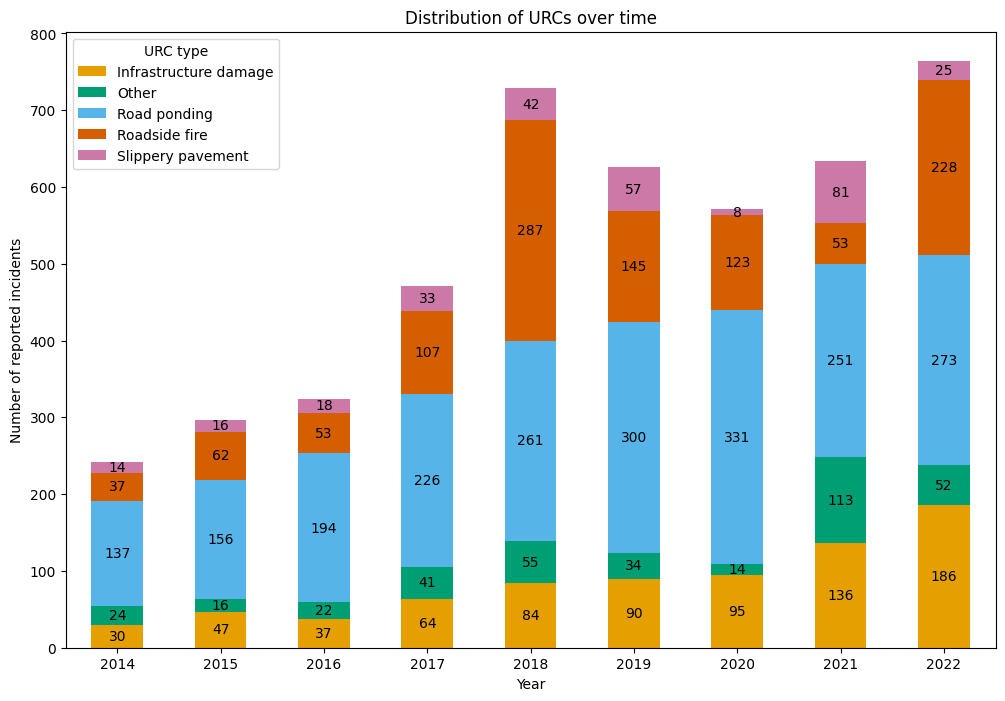

In [104]:
import matplotlib.colors as mcolors #Import colours

# Create a dataframe with the counts of each incident type per year
yearly_incident_counts = pd.DataFrame({
    '2014': df_2014['incident_type'].value_counts(),
    '2015': df_2015['incident_type'].value_counts(),
    '2016': df_2016['incident_type'].value_counts(),
    '2017': df_2017['incident_type'].value_counts(),
    '2018': df_2018['incident_type'].value_counts(),
    '2019': df_2019['incident_type'].value_counts(),
    '2020': df_2020['incident_type'].value_counts(),
    '2021': df_2021['incident_type'].value_counts(),
    '2022': df_2022['incident_type'].value_counts()
}).T # Transpose the dataframe to have years as index

# Define custom colors for each URC type
# The order of colors should match the order of `label_enc1.classes_`:
# ['Infrastructure damage', 'Other', 'Road ponding', 'Roadside fire', 'Slippery pavement']
custom_colors = ['#E69F00', '#009E73', '#56B4E9', '#D55E00', '#CC79A7']


# Plotting the stacked bar chart with custom colors
ax = yearly_incident_counts.plot(kind='bar', stacked=True, figsize=(12, 8), color=custom_colors)

# Adding title and labels
plt.title("Distribution of URCs over time")
plt.xlabel("Year")
plt.ylabel("Number of reported incidents")
plt.xticks(rotation=0)

# Set the legend labels to the incident type names
plt.legend(title='URC type', labels=label_enc1.classes_)

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%d')


plt.show()

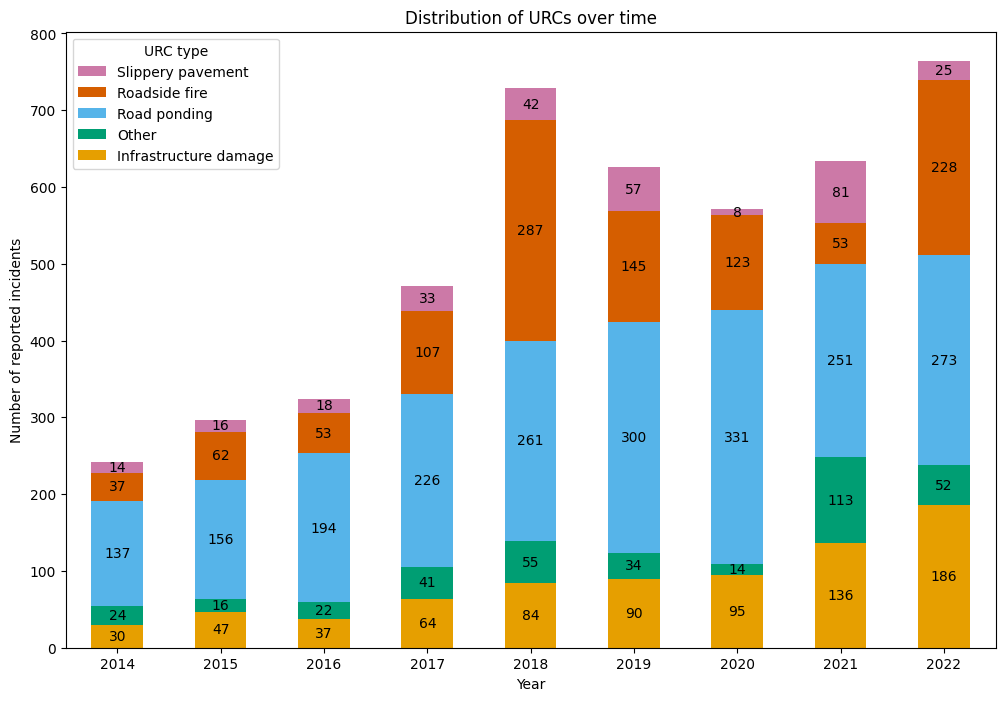

In [105]:
# Plotting the stacked bar chart with custom colors
ax = yearly_incident_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    color=custom_colors
)

urc_labels = [
    'Infrastructure damage',  # 0
    'Other',                  # 1
    'Road ponding',           # 2
    'Roadside fire',          # 3
    'Slippery pavement'       # 4
]

# Title and labels
plt.title("Distribution of URCs over time")
plt.xlabel("Year")
plt.ylabel("Number of reported incidents")
plt.xticks(rotation=0)

# Reverse legend order to match stacking
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], urc_labels[::-1], title='URC type')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%d')

plt.show()


DBSCAN clustering

In [106]:
#Load necessary libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from geopy.distance import great_circle
from shapely.geometry import MultiPoint

#Image saving
!pip install selenium #To save maps from folium
import selenium
import io
from PIL import Image
import geopandas as gpd

import random
random.seed(26)

coords = df1[['lat', 'lon']]
coords.head()

ERROR: Operation cancelled by user


,lat,lon
start_date,,
2014-01-21,51.903114,5.186706
2014-01-27,51.829996,5.254379
2014-06-02,52.118044,5.146372
2018-02-28,53.170201,6.890518
2014-04-24,52.140820,5.157969


In [107]:
kms_per_radian = 6371.0088
epsilon = 20/ kms_per_radian
db = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
cluster_labels = db.labels_
num_clusters = len(set(cluster_labels))
clusters = pd.Series([coords[cluster_labels == n] for n in range(num_clusters)])
print('Number of clusters: {}'.format(num_clusters))

Number of clusters: 3


In [108]:
from collections import Counter

df1['cluster'] = cluster_labels
print(Counter(df1['cluster']))

Counter({0: 3101, -1: 1235, 1: 322})


In [109]:
#Evaluate cluster representation

from sklearn import metrics

clusters = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit_predict(np.radians(coords))
metrics.silhouette_score(coords, clusters)

np.float64(0.4244109608500305)

In [110]:
cluster1 = df1[df1['cluster'] == -1]
cluster2 = df1[df1['cluster'] == 0]
cluster3 = df1[df1['cluster'] == 1]
print("Cluster 1 shape", cluster1.shape)
print("Cluster 2 shape", cluster2.shape)
print("Cluster 3 shape", cluster3.shape)
print("Unique incidents in cluster 1", cluster1['incident_type'].unique())
print("Unique incidents in cluster 2", cluster2['incident_type'].unique())
print("Unique incidents in cluster 3", cluster3['incident_type'].unique())

Cluster 1 shape (1235, 18)
Cluster 2 shape (3101, 18)
Cluster 3 shape (322, 18)
Unique incidents in cluster 1 [3 4 2 0 1]
Unique incidents in cluster 2 [1 2 0 3 4]
Unique incidents in cluster 3 [3 2 0 1 4]


In [111]:
#Mapping initial cluster

frames1 = [cluster1, cluster2, cluster3]

combined_clusters1 = pd.concat(frames1)

combined_clusters1['cluster'].value_counts()

,count
cluster,
0,3101
-1,1235
1,322


In [112]:
# Convert DataFrame to GeoDataFrame
combined_clusters1_gdf = gpd.GeoDataFrame(
    combined_clusters1,
    geometry=gpd.points_from_xy(combined_clusters1.lon, combined_clusters1.lat)
)

# Get coordinates in (lat, lon) format
combined_clusters_list1 = list(zip(combined_clusters1_gdf.lat, combined_clusters1_gdf.lon))

In [113]:
# Create map
com_map1 = folium.Map(location=(51.903, 5.187), zoom_start=8)

In [114]:
# Add markers
for i, coordinates in enumerate(combined_clusters_list1):
    cluster_label = combined_clusters1_gdf.cluster.iloc[i]

    if cluster_label == 0: #Central Netherlands (to sub-split)
        type_color = "red"
    elif cluster_label == 1: #Limburg
        type_color = "blue"
    elif cluster_label == -1: #Outskirts Netherlands
        type_color = "green"
    else:
        type_color = "black"

    folium.Marker(
        location=coordinates,
        icon=folium.Icon(color=type_color),
        popup=f"Cluster information<br>{cluster_label}"
    ).add_to(com_map1)

#com_map1

Subclustering cluster 2 (n = 3101)

In [115]:
coords2 = cluster2[['lat', 'lon']]
coords2.head()

,lat,lon
start_date,,
2014-01-21,51.903114,5.186706
2014-01-27,51.829996,5.254379
2014-06-02,52.118044,5.146372
2014-04-24,52.140820,5.157969
2014-04-24,52.096872,5.208125


In [116]:
random.seed(26)

kms_per_radian = 6371.0088
epsilon = 15/ kms_per_radian
db = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit(np.radians(coords2))
cluster_labels = db.labels_
num_clusters = len(set(cluster_labels))
clusters = pd.Series([coords2[cluster_labels == n] for n in range(num_clusters)])
print('Number of clusters: {}'.format(num_clusters))

Number of clusters: 3


In [117]:
cluster2['cluster'] = cluster_labels
print(cluster2['cluster'].value_counts())

cluster
 1    1281
 0    1060
-1     760
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [118]:
clusters = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit_predict(np.radians(coords2))
metrics.silhouette_score(coords2, clusters)

np.float64(0.3746308882730513)

In [119]:
cluster2a = cluster2[cluster2['cluster'] == -1]
cluster2b = cluster2[cluster2['cluster'] == 0]
cluster2c = cluster2[cluster2['cluster'] == 1]
#cluster2d = cluster2[cluster2['cluster'] == 2]

print(cluster2a.shape)
print(cluster2b.shape)
print(cluster2c.shape)
#print(cluster2d.shape)

(760, 18)
(1060, 18)
(1281, 18)


In [120]:
#Mapping all clusters

cluster_neg1 = df1[df1['cluster'] == -1]
cluster1 = df1[df1['cluster'] == 1]
cluster2a = cluster2[cluster2['cluster'] == -1]
cluster2b = cluster2[cluster2['cluster'] == 0]
cluster2c = cluster2[cluster2['cluster'] == 1]
#cluster2d = cluster2[cluster2['cluster'] == 2]

In [121]:
cluster_neg1.loc[cluster_neg1["cluster"] == -1, "cluster"] = 2
cluster1.loc[cluster1["cluster"] == 1, "cluster"] = 3

In [122]:
print("Cluster -1 shape:",cluster_neg1.shape)
print("Cluster 1 shape:",cluster1.shape)
print("Cluster 2a shape:",cluster2a.shape)
print("Cluster 2b shape:",cluster2b.shape)
print("Cluster 2c shape:",cluster2c.shape)
#print("Cluster 2d shape:", cluster2d.shape)

Cluster -1 shape: (1235, 18)
Cluster 1 shape: (322, 18)
Cluster 2a shape: (760, 18)
Cluster 2b shape: (1060, 18)
Cluster 2c shape: (1281, 18)


In [123]:
frames = [cluster2a, cluster2b, cluster2c, cluster1, cluster_neg1]

combined_clusters = pd.concat(frames)

In [124]:
combined_clusters['cluster'].value_counts()

,count
cluster,
1,1281
2,1235
0,1060
-1,760
3,322


In [125]:
# Convert DataFrame to GeoDataFrame
combined_clusters_gdf = gpd.GeoDataFrame(
    combined_clusters,
    geometry=gpd.points_from_xy(combined_clusters.lon, combined_clusters.lat)
)

# Get coordinates in (lat, lon) format
combined_clusters_list = list(zip(combined_clusters_gdf.lat, combined_clusters_gdf.lon))

In [126]:
# Create map
com_map = folium.Map(location=(51.903, 5.187), zoom_start=8)

In [127]:
# Add markers
#for i, coordinates in enumerate(combined_clusters_list):
#    cluster_label = combined_clusters_gdf.cluster.iloc[i]#

#    if cluster_label == 0: #Amsterdam - Utrecht
 #       type_color = "orange"
 #   elif cluster_label == 1: #Randstad
 #       type_color = "blue"
 #   elif cluster_label == -1: #Suburban (Brabant, Alkmaar)
 #       type_color = "red"
 #   elif cluster_label == 2: #Outskirts (North Holland)
 #       type_color = "#DBA49A" # Hex code requires #
 #   else:
   #     type_color = "purple" #3, Limburg
#
   # folium.CircleMarker(
 #       location=coordinates,
  #      radius=2,
  #      color=type_color,
 #       fill=True,
  #      fill_color=type_color,
   #     fill_opacity=0.7,
      #  popup=f"Cluster information<br>{cluster_label}"
 #   ).add_to(com_map)

#com_map

In [128]:
# Save map to HTML
com_map.save("combined_clusters_map.html")

In [129]:
com_map = folium.Map(location=(51.903, 5.187), zoom_start=8)

for i, coordinates in enumerate(combined_clusters_list):
    cluster_label = combined_clusters_gdf.cluster.iloc[i]

    # Assign colour-blind-safe hex colours (Okabe–Ito palette)
    if cluster_label == 0:  # Amsterdam - Utrecht
        type_color = "#E69F00"  # Orange
    elif cluster_label == 1:  # Randstad
        type_color = "#56B4E9"  # Sky Blue
    elif cluster_label == -1:  # Suburban (Brabant, Alkmaar)
        type_color = "#009E73"  # Bluish Green
    elif cluster_label == 2:  # Outskirts (North Holland)
        type_color = "#F0E442"  # Yellow
    else:  # Cluster 3 (Limburg)
        type_color = "#CC79A7"  # Reddish Purple

    # Circle markers only (no folium markers)
    folium.CircleMarker(
        location=coordinates,
        radius=5,
        color=type_color,
        fill=True,
        fill_color=type_color,
        fill_opacity=0.5
    ).add_to(com_map)

com_map


KeyboardInterrupt: 

In [ ]:
# Save map to HTML
com_map.save("cb_combined_clusters_map.html")

Data augmentation (bootstrapping) & preprocessing

In [ ]:
cluster_suburban = cluster2a.copy()
cluster_ams_ut = cluster2b.copy()
cluster_dh_rot = cluster2c.copy()
cluster_outlier = cluster_neg1.copy()
cluster_limburg = cluster1.copy()

In [ ]:
cluster_suburban = cluster_suburban.replace({'incident_type': {0: 'Infrastructure damage',
                                                             1: 'Other',
                                                     2: 'Road ponding',
                                                     3: 'Roadside fire',
                                                    4: 'Slippery pavement'}})
cluster_ams_ut = cluster_ams_ut.replace({'incident_type': {0: 'Infrastructure damage',
                                                             1: 'Other',
                                                     2: 'Road ponding',
                                                     3: 'Roadside fire',
                                                    4: 'Slippery pavement'}})
cluster_dh_rot = cluster_dh_rot.replace({'incident_type': {0: 'Infrastructure damage',
                                                             1: 'Other',
                                                     2: 'Road ponding',
                                                     3: 'Roadside fire',
                                                    4: 'Slippery pavement'}})
cluster_outlier = cluster_outlier.replace({'incident_type': {0: 'Infrastructure damage',
                                                             1: 'Other',
                                                     2: 'Road ponding',
                                                     3: 'Roadside fire',
                                                    4: 'Slippery pavement'}})
cluster_limburg = cluster_limburg.replace({'incident_type': {0: 'Infrastructure damage',
                                                             1: 'Other',
                                                            2: 'Road ponding',
                                                     3: 'Roadside fire',
                                                    4: 'Slippery pavement'}})

label_enc21 = skprep.LabelEncoder()
label_enc21.fit(cluster_suburban['incident_type'])
cluster_suburban['incident_type'] = label_enc21.transform(cluster_suburban['incident_type'])
cluster_ams_ut['incident_type'] = label_enc21.transform(cluster_ams_ut['incident_type'])
cluster_dh_rot['incident_type'] = label_enc21.transform(cluster_dh_rot['incident_type'])
cluster_outlier['incident_type'] = label_enc21.transform(cluster_outlier['incident_type'])
cluster_limburg['incident_type'] = label_enc21.transform(cluster_limburg['incident_type'])

In [ ]:
label_enc21_mapping = dict(zip(label_enc21.classes_, label_enc21.transform(label_enc21.classes_)))
print(label_enc21)

In [ ]:
print(cluster_suburban.shape)
print(cluster_ams_ut.shape)
print(cluster_dh_rot.shape)
print(cluster_outlier.shape)
print(cluster_limburg.shape)

#'Infrastructure damage': np.int64(0), 'Other': np.int64(1), 'Road ponding': np.int64(2),
#'Roadside fire': np.int64(3), 'Slippery pavement': np.int64(4), 'Zichtbaarheid': np.int64(5)

print("Cluster outlier", cluster_suburban['incident_type'].value_counts())
print("Cluster Amsterdam - Utrecht", cluster_ams_ut['incident_type'].value_counts())
print("Cluster Randstad", cluster_dh_rot['incident_type'].value_counts())
#print("Cluster Randstad", cluster_dh_rot['incident_type'].value_counts())
print("Cluster outlier2" ,cluster_outlier['incident_type'].value_counts())
print("Cluster Limburg", cluster_limburg['incident_type'].value_counts())

In [ ]:
def bootstrap_spatiotemporal_naive(df, n_samples=None):
    """
    Naively bootstraps spatiotemporal data (including time, lat, lon).
    Assumes rows are i.i.d., which may not be appropriate for time series.

    Parameters:
        df (pd.DataFrame): Must include 'timestamp', 'lat', 'lon', and features.
        n_samples (int): How many rows to sample. Defaults to len(df).

    Returns:
        pd.DataFrame: Bootstrapped dataset.
    """
    if n_samples is None:
        n_samples = len(df)
    return df.sample(n=n_samples, replace=True)

In [ ]:
bootstrap_suburban1 = bootstrap_suburban.to_csv('bootstrap_suburban.csv')
bootstrap_ams_ut1 = bootstrap_ams_ut.to_csv('bootstrap_ams_ut.csv')
bootstrap_dh_rot1 = bootstrap_dh_rot.to_csv('bootstrap_dh_rot.csv')
bootstrap_outlier1 = bootstrap_outlier.to_csv('bootstrap_outlier.csv')
bootstrap_limburg1 = bootstrap_limburg.to_csv('bootstrap_limburg.csv')

In [130]:
import random
random.seed(3)

bootstrap_suburban = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_suburban.csv")
bootstrap_ams_ut = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_ams_ut.csv")
bootstrap_dh_rot = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_dh_rot.csv")
bootstrap_outlier = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_outlier.csv")
bootstrap_limburg = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_limburg.csv")

#bootstrap_suburban = bootstrap_spatiotemporal_naive(cluster_suburban, n_samples=10000)
#bootstrap_ams_ut = bootstrap_spatiotemporal_naive(cluster_ams_ut, n_samples=10000)
#bootstrap_dh_rot = bootstrap_spatiotemporal_naive(cluster_dh_rot, n_samples=10000)
#bootstrap_outlier = bootstrap_spatiotemporal_naive(cluster_outlier, n_samples=8000) #A bit less for the outskirts due to less traffic
#bootstrap_limburg = bootstrap_spatiotemporal_naive(cluster_limburg, n_samples=5000) #Less for Limburg due to its size

print(bootstrap_suburban.shape)
print(bootstrap_ams_ut.shape)
print(bootstrap_dh_rot.shape)
print(bootstrap_outlier.shape)
print(bootstrap_limburg.shape)

(2280, 22)
(3180, 22)
(3843, 22)
(3705, 22)
(1000, 22)


In [ ]:
bootstrap_suburban.head()

In [131]:
print("Bootstrapped outlier cluster URC distribution", bootstrap_suburban['incident_type'].value_counts())
print("Bootstrapped cluster Amsterdam - Utrecht URC distribution", bootstrap_ams_ut['incident_type'].value_counts())
print("Bootstrapped cluster Randstad URC distribution", bootstrap_dh_rot['incident_type'].value_counts())
print("Bootstrapped cluster outlier2 URC distribution", bootstrap_outlier['incident_type'].value_counts())
print("Bootstrapped cluster Limburg URC distribution", bootstrap_limburg['incident_type'].value_counts())

#print("Original sample size - cluster outlier", cluster_suburban.shape, "Bootstrapped sample size", bootstrap_suburban.shape)
##print("Original sample size - Amsterdam - Utrecht", cluster_ams_ut.shape, "Bootstrapped sample size", bootstrap_ams_ut.shape)
#print("Original sample size - Randstad", cluster_dh_rot.shape, "Bootstrapped sample size", bootstrap_dh_rot.shape)
#print("Original sample size - outlier2", cluster_outlier.shape, "Bootstrapped sample size", bootstrap_outlier.shape)
#print("Original sample size - Limburg", cluster_limburg.shape, "Bootstrapped sample size", bootstrap_limburg.shape)

#'Infrastructure damage': np.int64(0), 'Other': np.int64(1), 'Road ponding': np.int64(2),
#'Roadside fire': np.int64(3), 'Slippery pavement': np.int64(4), 'Zichtbaarheid': np.int64(5)


Bootstrapped outlier cluster URC distribution incident_type
3    969
2    682
0    366
1    136
4    127
Name: count, dtype: int64
Bootstrapped cluster Amsterdam - Utrecht URC distribution incident_type
2    1354
3     643
0     437
4     374
1     372
Name: count, dtype: int64
Bootstrapped cluster Randstad URC distribution incident_type
2    2347
3     668
0     375
1     291
4     162
Name: count, dtype: int64
Bootstrapped cluster outlier2 URC distribution incident_type
2    1495
0     900
3     868
1     242
4     200
Name: count, dtype: int64
Bootstrapped cluster Limburg URC distribution incident_type
2    564
0    173
3    164
1     71
4     28
Name: count, dtype: int64


In [132]:
#Time series plotting - bootstrapped sets

bootstrap_suburban = bootstrap_suburban.sort_values(['start_date'], ascending=[True])
bootstrap_suburban = bootstrap_suburban.set_index('start_date')
print(bootstrap_suburban.head(3))

bootstrap_ams_ut = bootstrap_ams_ut.sort_values(['start_date'], ascending=[True])
bootstrap_ams_ut = bootstrap_ams_ut.set_index('start_date')
print(bootstrap_ams_ut.head(3))

bootstrap_dh_rot = bootstrap_dh_rot.sort_values(['start_date'], ascending=[True])
bootstrap_dh_rot = bootstrap_dh_rot.set_index('start_date')
print(bootstrap_dh_rot.head(3))

bootstrap_outlier = bootstrap_outlier.sort_values(['start_date'], ascending=[True])
bootstrap_outlier = bootstrap_outlier.set_index('start_date')
print(bootstrap_outlier.head(3))

bootstrap_limburg = bootstrap_limburg.sort_values(['start_date'], ascending=[True])
bootstrap_limburg = bootstrap_limburg.set_index('start_date')
print(bootstrap_limburg.head(3))

print("----------------------------------------")

df1 = df1.sort_values(['start_date'], ascending=[True])
df1 = df1.set_index('start_date')
print(df1.head(3))

                     start_time    end_date             end_time  \
start_date                                                         
2014-01-27  1900-01-01 11:52:00  2014-01-27  1900-01-01 12:48:00   
2014-01-27  1900-01-01 11:52:00  2014-01-27  1900-01-01 12:48:00   
2014-01-27  1900-01-01 11:52:00  2014-01-27  1900-01-01 12:48:00   

              incident_duration  incident_type  road_level       lon  \
start_date                                                             
2014-01-27  1900-01-01 00:56:00              2           1  5.254379   
2014-01-27  1900-01-01 00:56:00              2           1  5.254379   
2014-01-27  1900-01-01 00:56:00              2           1  5.254379   

                  lat  sum_prec (1h)  max_prec (5min)  ...  low_veg_%  \
start_date                                             ...              
2014-01-27  51.829996            0.0              0.0  ...       40.0   
2014-01-27  51.829996            0.0              0.0  ...       40.0   
2014-0

KeyError: "None of ['start_date'] are in the columns"

In [ ]:
print(bootstrap_suburban.head(3))

In [133]:
#Time indices per cluster for train, val and test
train1 = bootstrap_suburban.sort_index().loc['2014-01-01':'2020-07-01']
val1 = bootstrap_suburban.sort_index().loc['2020-07-01':'2021-07-01']
test1 = bootstrap_suburban.sort_index().loc['2021-07-01':]

train2 = bootstrap_ams_ut.sort_index().loc['2014-01-01':'2020-07-01']
val2 = bootstrap_ams_ut.sort_index().loc['2020-07-01':'2021-07-01']
test2 = bootstrap_ams_ut.sort_index().loc['2021-07-01':]

train3 = bootstrap_dh_rot.sort_index().loc['2014-01-01':'2020-07-01']
val3 = bootstrap_dh_rot.sort_index().loc['2020-07-01':'2021-07-01']
test3 = bootstrap_dh_rot.sort_index().loc['2021-07-01':]

train4 = bootstrap_outlier.sort_index().loc['2014-01-01':'2020-07-01']
val4 = bootstrap_outlier.sort_index().loc['2020-07-01':'2021-07-01']
test4 = bootstrap_outlier.sort_index().loc['2021-07-01':]

train5 = bootstrap_limburg.sort_index().loc['2014-01-01':'2020-07-01']
val5 = bootstrap_limburg.sort_index().loc['2020-07-01':'2021-07-01']
test5 = bootstrap_limburg.sort_index().loc['2021-07-01':]


#Receive indices for train, val, test (in row number)

N1 = len(bootstrap_suburban)
N2 = len(bootstrap_ams_ut)
N3 = len(bootstrap_dh_rot)
N4 = len(bootstrap_outlier)
N5 = len(bootstrap_limburg)

no_train1 = len(train1)
no_val1 = len(val1)
no_test1 = len(test1)
train_val1 = no_train1 + no_val1
val_test1 = (train_val1 + no_test1) - 1

no_train2 = len(train2)
no_val2 = len(val2)
no_test2 = len(test2)
train_val2 = no_train2 + no_val2
val_test2 = (train_val2 + no_test2) - 1

no_train3 = len(train3)
no_val3 = len(val3)
no_test3 = len(test3)
train_val3 = no_train3 + no_val3
val_test3 = (train_val3 + no_test3) - 1

no_train4 = len(train4)
no_val4 = len(val4)
no_test4 = len(test4)
train_val4 = no_train4 + no_val4
val_test4 = (train_val4 + no_test4) - 1

no_train5 = len(train5)
no_val5 = len(val5)
no_test5 = len(test5)
train_val5 = no_train5 + no_val5
val_test5 = (train_val5 + no_test5) - 1

Probability heatmaps generation

In [134]:
#Load and print the bootstrapped samples

bootstrap_suburban = pd.read_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_suburban.csv', index_col=0)
bootstrap_ams_ut = pd.read_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_ams_ut.csv', index_col=0)
bootstrap_dh_rot = pd.read_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_dh_rot.csv', index_col=0)
bootstrap_outlier = pd.read_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_outlier.csv', index_col=0)
bootstrap_limburg = pd.read_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_limburg.csv', index_col=0)

print("Bootstrapped outlier cluster URC distribution", bootstrap_suburban['incident_type'].value_counts())
print("Bootstrapped cluster Amsterdam - Utrecht URC distribution", bootstrap_ams_ut['incident_type'].value_counts())
print("Bootstrapped cluster Randstad URC distribution", bootstrap_dh_rot['incident_type'].value_counts())
print("Bootstrapped cluster outlier2 URC distribution", bootstrap_outlier['incident_type'].value_counts())
print("Bootstrapped cluster Limburg URC distribution", bootstrap_limburg['incident_type'].value_counts())

#print("Original sample size - cluster outlier", cluster_suburban.shape, "Bootstrapped sample size", bootstrap_suburban.shape)
#print("Original sample size - Amsterdam - Utrecht", cluster_ams_ut.shape, "Bootstrapped sample size", bootstrap_ams_ut.shape)
#print("Original sample size - Randstad", cluster_dh_rot.shape, "Bootstrapped sample size", bootstrap_dh_rot.shape)
#print("Original sample size - outlier2", cluster_outlier.shape, "Bootstrapped sample size", bootstrap_outlier.shape)
#print("Original sample size - Limburg", cluster_limburg.shape, "Bootstrapped sample size", bootstrap_limburg.shape)


Bootstrapped outlier cluster URC distribution incident_type
3    969
2    682
0    366
1    136
4    127
Name: count, dtype: int64
Bootstrapped cluster Amsterdam - Utrecht URC distribution incident_type
2    1354
3     643
0     437
4     374
1     372
Name: count, dtype: int64
Bootstrapped cluster Randstad URC distribution incident_type
2    2347
3     668
0     375
1     291
4     162
Name: count, dtype: int64
Bootstrapped cluster outlier2 URC distribution incident_type
2    1495
0     900
3     868
1     242
4     200
Name: count, dtype: int64
Bootstrapped cluster Limburg URC distribution incident_type
2    564
0    173
3    164
1     71
4     28
Name: count, dtype: int64


In [ ]:
bootstrap_suburban.head()

In [135]:
#Data splitting per cluster

train1 = bootstrap_suburban.loc['2014-01-01':'2020-07-01']
val1 = bootstrap_suburban.loc['2020-07-01':'2021-07-01']
test1 = bootstrap_suburban.loc['2021-07-01':]

train2 = bootstrap_ams_ut.loc['2014-01-01':'2020-07-01']
val2 = bootstrap_ams_ut.loc['2020-07-01':'2021-07-01']
test2 = bootstrap_ams_ut.loc['2021-07-01':]

train3 = bootstrap_dh_rot.loc['2014-01-01':'2020-07-01']
val3 = bootstrap_dh_rot.loc['2020-07-01':'2021-07-01']
test3 = bootstrap_dh_rot.loc['2021-07-01':]

train4 = bootstrap_outlier.loc['2014-01-01':'2020-07-01']
val4 = bootstrap_outlier.loc['2020-07-01':'2021-07-01']
test4 = bootstrap_outlier.loc['2021-07-01':]

train5 = bootstrap_limburg.loc['2014-01-01':'2020-07-01']
val5 = bootstrap_limburg.loc['2020-07-01':'2021-07-01']
test5 = bootstrap_limburg.loc['2021-07-01':]

Preprocess test probability datasets for chloropleth mapping

In [136]:
#Acquire the coords

coords1 = test1[['lat', 'lon']]
coords1.head()
coords2 = test2[['lat', 'lon']]
coords2.head()
coords3 = test3[['lat', 'lon']]
coords3.head()
coords4 = test4[['lat', 'lon']]
coords4.head()
coords5 = test5[['lat', 'lon']]

print(coords1.shape)
print(coords2.shape)
print(coords3.shape)
print(coords4.shape)
print(coords5.shape)

(494, 2)
(678, 2)
(753, 2)
(1165, 2)
(172, 2)


In [144]:
#Load test probabilities

test1_xgb = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_xgb1.csv")
test1_xgb.drop(columns=test1_xgb.columns[0], axis=1, inplace=True)
test2_xgb = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_xgb2.csv")
test2_xgb.drop(columns=test2_xgb.columns[0], axis=1, inplace=True)
test3_xgb = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_xgb3.csv")
test3_xgb.drop(columns=test3_xgb.columns[0], axis=1, inplace=True)
test4_xgb = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_xgb4.csv")
test4_xgb.drop(columns=test4_xgb.columns[0], axis=1, inplace=True)
test5_xgb = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_xgb5.csv")
test5_xgb.drop(columns=test5_xgb.columns[0], axis=1, inplace=True)

rf_test1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_rf1.csv")
rf_test1.drop(columns=rf_test1.columns[0], axis=1, inplace=True)
rf_test2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_rf2.csv")
rf_test2.drop(columns=rf_test2.columns[0], axis=1, inplace=True)
rf_test3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_rf3.csv")
rf_test3.drop(columns=rf_test3.columns[0], axis=1, inplace=True)
rf_test4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_rf4.csv")
rf_test4.drop(columns=rf_test4.columns[0], axis=1, inplace=True)
rf_test5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_rf5.csv")
rf_test5.drop(columns=rf_test5.columns[0], axis=1, inplace=True)

lr_test1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lr1.csv")
lr_test1.drop(columns=lr_test1.columns[0], axis=1, inplace=True)
lr_test2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lr2.csv")
lr_test2.drop(columns=lr_test2.columns[0], axis=1, inplace=True)
lr_test3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lr3.csv")
lr_test3.drop(columns=lr_test3.columns[0], axis=1, inplace=True)
lr_test4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lr4.csv")
lr_test4.drop(columns=lr_test4.columns[0], axis=1, inplace=True)
lr_test5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lr5.csv")
lr_test5.drop(columns=lr_test5.columns[0], axis=1, inplace=True)

lstm_test1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lstm1.csv")
lstm_test1.drop(columns=lstm_test1.columns[0], axis=1, inplace=True)
lstm_test2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lstm2.csv")
lstm_test2.drop(columns=lstm_test2.columns[0], axis=1, inplace=True)
lstm_test3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lstm3.csv")
lstm_test3.drop(columns=lstm_test3.columns[0], axis=1, inplace=True)
lstm_test4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lstm4.csv")
lstm_test4.drop(columns=lstm_test4.columns[0], axis=1, inplace=True)
lstm_test5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lstm5.csv")
lstm_test5.drop(columns=lstm_test5.columns[0], axis=1, inplace=True)

blstm_test1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_blstm1.csv")
blstm_test1.drop(columns=blstm_test1.columns[0], axis=1, inplace=True)
blstm_test2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_blstm2.csv")
blstm_test2.drop(columns=blstm_test2.columns[0], axis=1, inplace=True)
blstm_test3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_blstm3.csv")
blstm_test3.drop(columns=blstm_test3.columns[0], axis=1, inplace=True)
blstm_test4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_blstm4.csv")
blstm_test4.drop(columns=blstm_test4.columns[0], axis=1, inplace=True)
blstm_test5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_blstm5.csv")
blstm_test5.drop(columns=blstm_test5.columns[0], axis=1, inplace=True)

gat_test1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gat1.csv")
gat_test1.drop(columns=gat_test1.columns[0], axis=1, inplace=True)
gat_test2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gat2.csv")
gat_test2.drop(columns=gat_test2.columns[0], axis=1, inplace=True)
gat_test3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gat3.csv")
gat_test3.drop(columns=gat_test3.columns[0], axis=1, inplace=True)
gat_test4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gat4.csv")
gat_test4.drop(columns=gat_test4.columns[0], axis=1, inplace=True)
gat_test5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gat5.csv")
gat_test5.drop(columns=gat_test5.columns[0], axis=1, inplace=True)

#gcn_test1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/test_gcn1.csv")
#gcn_test1.drop(columns=gcn_test1.columns[0], axis=1, inplace=True)
#gcn_test2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/test_gcn2.csv")
#gcn_test2.drop(columns=gcn_test2.columns[0], axis=1, inplace=True)
#gcn_test3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/test_gcn3.csv")
#gcn_test3.drop(columns=gcn_test3.columns[0], axis=1, inplace=True)
#gcn_test4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/test_gcn4.csv")
#gcn_test4.drop(columns=gcn_test4.columns[0], axis=1, inplace=True)
#gcn_test5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/test_gcn5.csv")
#gcn_test5.drop(columns=gcn_test5.columns[0], axis=1, inplace=True)

gcn_test1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcn1.csv")
gcn_test1.drop(columns=gcn_test1.columns[0], axis=1, inplace=True)
gcn_test2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcn2.csv")
gcn_test2.drop(columns=gcn_test2.columns[0], axis=1, inplace=True)
gcn_test3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcn3.csv")
gcn_test3.drop(columns=gcn_test3.columns[0], axis=1, inplace=True)
gcn_test4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcn4.csv")
gcn_test4.drop(columns=gcn_test4.columns[0], axis=1, inplace=True)
gcn_test5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcn5.csv")
gcn_test5.drop(columns=gcn_test5.columns[0], axis=1, inplace=True)

gcnblstm_test1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcnblstm1.csv")
gcnblstm_test1.drop(columns=gcnblstm_test1.columns[0], axis=1, inplace=True)
gcnblstm_test2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcnblstm2.csv")
gcnblstm_test2.drop(columns=gcnblstm_test2.columns[0], axis=1, inplace=True)
gcnblstm_test3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcnblstm3.csv")
gcnblstm_test3.drop(columns=gcnblstm_test3.columns[0], axis=1, inplace=True)
gcnblstm_test4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcnblstm4.csv")
gcnblstm_test4.drop(columns=gcnblstm_test4.columns[0], axis=1, inplace=True)
gcnblstm_test5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcnblstm5.csv")
gcnblstm_test5.drop(columns=gcnblstm_test5.columns[0], axis=1, inplace=True)

gatblstm_test1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gatblstm1.csv")
gatblstm_test1.drop(columns=gatblstm_test1.columns[0], axis=1, inplace=True)
gatblstm_test2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gatblstm2.csv")
gatblstm_test2.drop(columns=gatblstm_test2.columns[0], axis=1, inplace=True)
gatblstm_test3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gatblstm3.csv")
gatblstm_test3.drop(columns=gatblstm_test3.columns[0], axis=1, inplace=True)
gatblstm_test4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gatblstm4.csv")
gatblstm_test4.drop(columns=gatblstm_test4.columns[0], axis=1, inplace=True)
gatblstm_test5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gatblstm5.csv")
gatblstm_test5.drop(columns=gatblstm_test5.columns[0], axis=1, inplace=True)


In [145]:
test1_xgb = test1_xgb.reset_index(drop=True)
test2_xgb = test2_xgb.reset_index(drop=True)
test3_xgb = test3_xgb.reset_index(drop=True)
test4_xgb = test4_xgb.reset_index(drop=True)
test5_xgb = test5_xgb.reset_index(drop=True)

rf_test1 = rf_test1.reset_index(drop=True)
rf_test2 = rf_test2.reset_index(drop=True)
rf_test3 = rf_test3.reset_index(drop=True)
rf_test4 = rf_test4.reset_index(drop=True)
rf_test5 = rf_test5.reset_index(drop=True)

lr_test1 = lr_test1.reset_index(drop=True)
lr_test2 = lr_test2.reset_index(drop=True)
lr_test3 = lr_test3.reset_index(drop=True)
lr_test4 = lr_test4.reset_index(drop=True)
lr_test5 = lr_test5.reset_index(drop=True)

lstm_test1 = lstm_test1.reset_index(drop=True)
lstm_test2 = lstm_test2.reset_index(drop=True)
lstm_test3 = lstm_test3.reset_index(drop=True)
lstm_test4 = lstm_test4.reset_index(drop=True)
lstm_test5 = lstm_test5.reset_index(drop=True)

blstm_test1 = blstm_test1.reset_index(drop=True)
blstm_test2 = blstm_test2.reset_index(drop=True)
blstm_test3 = blstm_test3.reset_index(drop=True)
blstm_test4 = blstm_test4.reset_index(drop=True)
blstm_test5 = blstm_test5.reset_index(drop=True)

# Rename columns for LSTM and BiLSTM DataFrames
col_mapping = {'0': 'Infrastructure damage', '1': 'Other', '2': 'Road ponding', '3': 'Roadside fire', '4': 'Slippery pavement',
               0: 'Infrastructure damage', 1: 'Other', 2: 'Road ponding', 3: 'Roadside fire', 4: 'Slippery pavement'}

lstm_test1.rename(columns=col_mapping, inplace=True)
lstm_test2.rename(columns=col_mapping, inplace=True)
lstm_test3.rename(columns=col_mapping, inplace=True)
lstm_test4.rename(columns=col_mapping, inplace=True)
lstm_test5.rename(columns=col_mapping, inplace=True)

blstm_test1.rename(columns=col_mapping, inplace=True)
blstm_test2.rename(columns=col_mapping, inplace=True)
blstm_test3.rename(columns=col_mapping, inplace=True)
blstm_test4.rename(columns=col_mapping, inplace=True)
blstm_test5.rename(columns=col_mapping, inplace=True)

gat_test1 = gat_test1.reset_index(drop=True)
gat_test2 = gat_test2.reset_index(drop=True)
gat_test3 = gat_test3.reset_index(drop=True)
gat_test4 = gat_test4.reset_index(drop=True)
gat_test5 = gat_test5.reset_index(drop=True)

gcn_test1 = gcn_test1.reset_index(drop=True)
gcn_test2 = gcn_test2.reset_index(drop=True)
gcn_test3 = gcn_test3.reset_index(drop=True)
gcn_test4 = gcn_test4.reset_index(drop=True)
gcn_test5 = gcn_test5.reset_index(drop=True)

gcnblstm_test1 = gcnblstm_test1.reset_index(drop=True)
gcnblstm_test2 = gcnblstm_test2.reset_index(drop=True)
gcnblstm_test3 = gcnblstm_test3.reset_index(drop=True)
gcnblstm_test4 = gcnblstm_test4.reset_index(drop=True)
gcnblstm_test5 = gcnblstm_test5.reset_index(drop=True)

gatblstm_test1 = gatblstm_test1.reset_index(drop=True)
gatblstm_test2 = gatblstm_test2.reset_index(drop=True)
gatblstm_test3 = gatblstm_test3.reset_index(drop=True)
gatblstm_test4 = gatblstm_test4.reset_index(drop=True)
gatblstm_test5 = gatblstm_test5.reset_index(drop=True)

In [146]:
merged1_xgb = test1_xgb.join(coords1.reset_index().rename(columns={'index': 'start_date'}))
merged2_xgb = test2_xgb.join(coords2.reset_index().rename(columns={'index': 'start_date'}))
merged3_xgb = test3_xgb.join(coords3.reset_index().rename(columns={'index': 'start_date'}))
merged4_xgb = test4_xgb.join(coords4.reset_index().rename(columns={'index': 'start_date'}))
merged5_xgb = test5_xgb.join(coords5.reset_index().rename(columns={'index': 'start_date'}))

merged1_rf = rf_test1.join(coords1.reset_index().rename(columns={'index': 'start_date'}))
merged2_rf = rf_test2.join(coords2.reset_index().rename(columns={'index': 'start_date'}))
merged3_rf = rf_test3.join(coords3.reset_index().rename(columns={'index': 'start_date'}))
merged4_rf = rf_test4.join(coords4.reset_index().rename(columns={'index': 'start_date'}))
merged5_rf = rf_test5.join(coords5.reset_index().rename(columns={'index': 'start_date'}))

merged1_lr = lr_test1.join(coords1.reset_index().rename(columns={'index': 'start_date'}))
merged2_lr = lr_test2.join(coords2.reset_index().rename(columns={'index': 'start_date'}))
merged3_lr = lr_test3.join(coords3.reset_index().rename(columns={'index': 'start_date'}))
merged4_lr = lr_test4.join(coords4.reset_index().rename(columns={'index': 'start_date'}))
merged5_lr = lr_test5.join(coords5.reset_index().rename(columns={'index': 'start_date'}))

merged1_lstm = lstm_test1.join(coords1.reset_index().rename(columns={'index': 'start_date'}))
merged2_lstm = lstm_test2.join(coords2.reset_index().rename(columns={'index': 'start_date'}))
merged3_lstm = lstm_test3.join(coords3.reset_index().rename(columns={'index': 'start_date'}))
merged4_lstm = lstm_test4.join(coords4.reset_index().rename(columns={'index': 'start_date'}))
merged5_lstm = lstm_test5.join(coords5.reset_index().rename(columns={'index': 'start_date'}))

merged1_blstm = blstm_test1.join(coords1.reset_index().rename(columns={'index': 'start_date'}))
merged2_blstm = blstm_test2.join(coords2.reset_index().rename(columns={'index': 'start_date'}))
merged3_blstm = blstm_test3.join(coords3.reset_index().rename(columns={'index': 'start_date'}))
merged4_blstm = blstm_test4.join(coords4.reset_index().rename(columns={'index': 'start_date'}))
merged5_blstm = blstm_test5.join(coords5.reset_index().rename(columns={'index': 'start_date'}))

merged1_gat = gat_test1.join(coords1.reset_index().rename(columns={'index': 'start_date'}))
merged2_gat = gat_test2.join(coords2.reset_index().rename(columns={'index': 'start_date'}))
merged3_gat = gat_test3.join(coords3.reset_index().rename(columns={'index': 'start_date'}))
merged4_gat = gat_test4.join(coords4.reset_index().rename(columns={'index': 'start_date'}))
merged5_gat = gat_test5.join(coords5.reset_index().rename(columns={'index': 'start_date'}))

merged1_gcn = gcn_test1.join(coords1.reset_index().rename(columns={'index': 'start_date'}))
merged2_gcn = gcn_test2.join(coords2.reset_index().rename(columns={'index': 'start_date'}))
merged3_gcn = gcn_test3.join(coords3.reset_index().rename(columns={'index': 'start_date'}))
merged4_gcn = gcn_test4.join(coords4.reset_index().rename(columns={'index': 'start_date'}))
merged5_gcn = gcn_test5.join(coords5.reset_index().rename(columns={'index': 'start_date'}))

merged1_gcnblstm = gcnblstm_test1.join(coords1.reset_index().rename(columns={'index': 'start_date'}))
merged2_gcnblstm = gcnblstm_test2.join(coords2.reset_index().rename(columns={'index': 'start_date'}))
merged3_gcnblstm = gcnblstm_test3.join(coords3.reset_index().rename(columns={'index': 'start_date'}))
merged4_gcnblstm = gcnblstm_test4.join(coords4.reset_index().rename(columns={'index': 'start_date'}))
merged5_gcnblstm = gcnblstm_test5.join(coords5.reset_index().rename(columns={'index': 'start_date'}))

merged1_gatblstm = gatblstm_test1.join(coords1.reset_index().rename(columns={'index': 'start_date'}))
merged2_gatblstm = gatblstm_test2.join(coords2.reset_index().rename(columns={'index': 'start_date'}))
merged3_gatblstm = gatblstm_test3.join(coords3.reset_index().rename(columns={'index': 'start_date'}))
merged4_gatblstm = gatblstm_test4.join(coords4.reset_index().rename(columns={'index': 'start_date'}))
merged5_gatblstm = gatblstm_test5.join(coords5.reset_index().rename(columns={'index': 'start_date'}))

In [147]:
#Extract ground truths

y_true1 = test1['incident_type']
y_true2 = test2['incident_type']
y_true3 = test3['incident_type']
y_true4 = test4['incident_type']
y_true5 = test5['incident_type']

In [148]:
#Argmax the probabilities for the final prediction class

argmax1_xgb = np.argmax(test1_xgb, axis=1)
argmax2_xgb = np.argmax(test2_xgb, axis=1)
argmax3_xgb = np.argmax(test3_xgb, axis=1)
argmax4_xgb = np.argmax(test4_xgb, axis=1)
argmax5_xgb = np.argmax(test5_xgb, axis=1)

argmax1_rf = np.argmax(rf_test1, axis=1)
argmax2_rf = np.argmax(rf_test2, axis=1)
argmax3_rf = np.argmax(rf_test3, axis=1)
argmax4_rf = np.argmax(rf_test4, axis=1)
argmax5_rf = np.argmax(rf_test5, axis=1)

argmax1_lr = np.argmax(lr_test1, axis=1)
argmax2_lr = np.argmax(lr_test2, axis=1)
argmax3_lr = np.argmax(lr_test3, axis=1)
argmax4_lr = np.argmax(lr_test4, axis=1)
argmax5_lr = np.argmax(lr_test5, axis=1)

argmax1_lstm = np.argmax(lstm_test1, axis=1)
argmax2_lstm = np.argmax(lstm_test2, axis=1)
argmax3_lstm = np.argmax(lstm_test3, axis=1)
argmax4_lstm = np.argmax(lstm_test4, axis=1)
argmax5_lstm = np.argmax(lstm_test5, axis=1)

argmax1_blstm = np.argmax(blstm_test1, axis=1)
argmax2_blstm = np.argmax(blstm_test2, axis=1)
argmax3_blstm = np.argmax(blstm_test3, axis=1)
argmax4_blstm = np.argmax(blstm_test4, axis=1)
argmax5_blstm = np.argmax(blstm_test5, axis=1)

argmax1_gat = np.argmax(gat_test1, axis=1)
argmax2_gat = np.argmax(gat_test2, axis=1)
argmax3_gat = np.argmax(gat_test3, axis=1)
argmax4_gat = np.argmax(gat_test4, axis=1)
argmax5_gat = np.argmax(gat_test5, axis=1)

argmax1_gcn = np.argmax(gcn_test1, axis=1)
argmax2_gcn = np.argmax(gcn_test2, axis=1)
argmax3_gcn = np.argmax(gcn_test3, axis=1)
argmax4_gcn = np.argmax(gcn_test4, axis=1)
argmax5_gcn = np.argmax(gcn_test5, axis=1)

argmax1_gcnblstm1 = np.argmax(gcnblstm_test1, axis=1)
argmax2_gcnblstm2 = np.argmax(gcnblstm_test2, axis=1)
argmax3_gcnblstm3 = np.argmax(gcnblstm_test3, axis=1)
argmax4_gcnblstm4 = np.argmax(gcnblstm_test4, axis=1)
argmax5_gcnblstm5 = np.argmax(gcnblstm_test5, axis=1)

argmax1_gatblstm1 = np.argmax(gatblstm_test1, axis=1)
argmax2_gatblstm2 = np.argmax(gatblstm_test2, axis=1)
argmax3_gatblstm3 = np.argmax(gatblstm_test3, axis=1)
argmax4_gatblstm4 = np.argmax(gatblstm_test4, axis=1)
argmax5_gatblstm5 = np.argmax(gatblstm_test5, axis=1)

In [ ]:
argmax1_xgb.shape

In [149]:
#Check if all lenghts match

print("XGBoost length comparison")
print(coords1.shape, test1_xgb.shape, len(merged1_xgb), len(y_true1), argmax1_xgb.shape)
print(coords2.shape, test2_xgb.shape, len(merged2_xgb), len(y_true2), argmax2_xgb.shape)
print(coords3.shape, test3_xgb.shape, len(merged3_xgb), len(y_true3), argmax3_xgb.shape)
print(coords4.shape, test4_xgb.shape, len(merged4_xgb), len(y_true4), argmax4_xgb.shape)
print(coords5.shape, test5_xgb.shape, len(merged5_xgb), len(y_true5), argmax5_xgb.shape)

print("Random Forest length comparison")
print(coords1.shape, rf_test1.shape, len(merged1_rf), len(y_true1), argmax1_rf.shape)
print(coords2.shape, rf_test2.shape, len(merged2_rf), len(y_true2), argmax2_rf.shape)
print(coords3.shape, rf_test3.shape, len(merged3_rf), len(y_true3), argmax3_rf.shape)
print(coords4.shape, rf_test4.shape, len(merged4_rf), len(y_true4), argmax4_rf.shape)
print(coords5.shape, rf_test5.shape, len(merged5_rf), len(y_true5), argmax5_rf.shape)

print("Logistic Regression length comparison")
print(coords1.shape, lr_test1.shape, len(merged1_lr), len(y_true1), argmax1_lr.shape)
print(coords2.shape, lr_test2.shape, len(merged2_lr), len(y_true2), argmax2_lr.shape)
print(coords3.shape, lr_test3.shape, len(merged3_lr), len(y_true3), argmax3_lr.shape)
print(coords4.shape, lr_test4.shape, len(merged4_lr), len(y_true4), argmax4_lr.shape)
print(coords5.shape, lr_test5.shape, len(merged5_lr), len(y_true5), argmax5_lr.shape)

print("LSTM length comparison")
print(coords1.shape, lstm_test1.shape, len(merged1_lstm), len(y_true1), argmax1_lstm.shape)
print(coords2.shape, lstm_test2.shape, len(merged2_lstm), len(y_true2), argmax2_lstm.shape)
print(coords3.shape, lstm_test3.shape, len(merged3_lstm), len(y_true3), argmax3_lstm.shape)
print(coords4.shape, lstm_test4.shape, len(merged4_lstm), len(y_true4), argmax4_lstm.shape)
print(coords5.shape, lstm_test5.shape, len(merged5_lstm), len(y_true5), argmax5_lstm.shape)

print("BiLSTM length comparison")
print(coords1.shape, blstm_test1.shape, len(merged1_blstm), len(y_true1), argmax1_blstm.shape)
print(coords2.shape, blstm_test2.shape, len(merged2_blstm), len(y_true2), argmax2_blstm.shape)
print(coords3.shape, blstm_test3.shape, len(merged3_blstm), len(y_true3), argmax3_blstm.shape)
print(coords4.shape, blstm_test4.shape, len(merged4_blstm), len(y_true4), argmax4_blstm.shape)
print(coords5.shape, blstm_test5.shape, len(merged5_blstm), len(y_true5), argmax5_blstm.shape)

print("GAT length comparison")
print(coords1.shape, gat_test1.shape, len(merged1_gat), len(y_true1), argmax1_gat.shape)
print(coords2.shape, gat_test2.shape, len(merged2_gat), len(y_true2), argmax2_gat.shape)
print(coords3.shape, gat_test3.shape, len(merged3_gat), len(y_true3), argmax3_gat.shape)
print(coords4.shape, gat_test4.shape, len(merged4_gat), len(y_true4), argmax4_gat.shape)
print(coords5.shape, gat_test5.shape, len(merged5_gat), len(y_true5), argmax5_gat.shape)

print("GCN length comparison")
print(coords1.shape, gcn_test1.shape, len(merged1_gcn), len(y_true1), argmax1_gcn.shape)
print(coords2.shape, gcn_test2.shape, len(merged2_gcn), len(y_true2), argmax2_gcn.shape)
print(coords3.shape, gcn_test3.shape, len(merged3_gcn), len(y_true3), argmax3_gcn.shape)
print(coords4.shape, gcn_test4.shape, len(merged4_gcn), len(y_true4), argmax4_gcn.shape)
print(coords5.shape, gcn_test5.shape, len(merged5_gcn), len(y_true5), argmax5_gcn.shape)

print("GCN-BLSTM length comparison")
print(coords1.shape, gcnblstm_test1.shape, len(merged1_gcnblstm), len(y_true1), argmax1_gcnblstm1.shape)
print(coords2.shape, gcnblstm_test2.shape, len(merged2_gcnblstm), len(y_true2), argmax2_gcnblstm2.shape)
print(coords3.shape, gcnblstm_test3.shape, len(merged3_gcnblstm), len(y_true3), argmax3_gcnblstm3.shape)
print(coords4.shape, gcnblstm_test4.shape, len(merged4_gcnblstm), len(y_true4), argmax4_gcnblstm4.shape)
print(coords5.shape, gcnblstm_test5.shape, len(merged5_gcnblstm), len(y_true5), argmax5_gcnblstm5.shape)

print("GAT-BLSTM length comparison")
print(coords1.shape, gatblstm_test1.shape, len(merged1_gatblstm), len(y_true1), argmax1_gatblstm1.shape)
print(coords2.shape, gatblstm_test2.shape, len(merged2_gatblstm), len(y_true2), argmax2_gatblstm2.shape)
print(coords3.shape, gatblstm_test3.shape, len(merged3_gatblstm), len(y_true3), argmax3_gatblstm3.shape)
print(coords4.shape, gatblstm_test4.shape, len(merged4_gatblstm), len(y_true4), argmax4_gatblstm4.shape)
print(coords5.shape, gatblstm_test5.shape, len(merged5_gatblstm), len(y_true5), argmax5_gatblstm5.shape)

XGBoost length comparison
(494, 2) (494, 5) 494 494 (494,)
(678, 2) (678, 5) 678 678 (678,)
(753, 2) (753, 5) 753 753 (753,)
(1165, 2) (1165, 5) 1165 1165 (1165,)
(172, 2) (172, 5) 172 172 (172,)
Random Forest length comparison
(494, 2) (494, 5) 494 494 (494,)
(678, 2) (678, 5) 678 678 (678,)
(753, 2) (753, 5) 753 753 (753,)
(1165, 2) (1165, 5) 1165 1165 (1165,)
(172, 2) (172, 5) 172 172 (172,)
Logistic Regression length comparison
(494, 2) (494, 5) 494 494 (494,)
(678, 2) (678, 5) 678 678 (678,)
(753, 2) (753, 5) 753 753 (753,)
(1165, 2) (1165, 5) 1165 1165 (1165,)
(172, 2) (172, 5) 172 172 (172,)
LSTM length comparison
(494, 2) (474, 5) 474 494 (474,)
(678, 2) (658, 5) 658 678 (658,)
(753, 2) (733, 5) 733 753 (733,)
(1165, 2) (1145, 5) 1145 1165 (1145,)
(172, 2) (152, 5) 152 172 (152,)
BiLSTM length comparison
(494, 2) (474, 5) 474 494 (474,)
(678, 2) (658, 5) 658 678 (658,)
(753, 2) (733, 5) 733 753 (733,)
(1165, 2) (1145, 5) 1145 1165 (1145,)
(172, 2) (152, 5) 152 172 (152,)
GAT le

In [150]:
#(B)LSTM and GCN/GAT-BLSTM preprocessing to bring to the right length

#Cut test matrices just as long as temporal models (0 - len(temporal models))

temp_y_true1 = y_true1[0:len(merged1_lstm)]
temp_y_true2 = y_true2[0:len(merged2_lstm)]
temp_y_true3 = y_true3[0:len(merged3_lstm)]
temp_y_true4 = y_true4[0:len(merged4_lstm)]
temp_y_true5 = y_true5[0:len(merged5_lstm)]

print(temp_y_true1.shape, temp_y_true2.shape, temp_y_true3.shape, temp_y_true4.shape, temp_y_true5.shape)
print(argmax1_lstm.shape, argmax2_lstm.shape, argmax3_lstm.shape, argmax4_lstm.shape, argmax5_lstm.shape)

(474,) (658,) (733,) (1145,) (152,)
(474,) (658,) (733,) (1145,) (152,)


In [151]:
#Match indices of true predictions with the coordinates

xgb_tp_indices1 = np.where(y_true1 == argmax1_xgb)[0]
xgb_tp_indices2 = np.where(y_true2 == argmax2_xgb)[0]
xgb_tp_indices3 = np.where(y_true3 == argmax3_xgb)[0]
xgb_tp_indices4 = np.where(y_true4 == argmax4_xgb)[0]
xgb_tp_indices5 = np.where(y_true5 == argmax5_xgb)[0]

# Extract only those cases
xgb_tp_probs1 = merged1_xgb[merged1_xgb.index.isin(xgb_tp_indices1)]
xgb_tp_probs2 = merged2_xgb[merged2_xgb.index.isin(xgb_tp_indices2)]
xgb_tp_probs3 = merged3_xgb[merged3_xgb.index.isin(xgb_tp_indices3)]
xgb_tp_probs4 = merged4_xgb[merged4_xgb.index.isin(xgb_tp_indices4)]
xgb_tp_probs5 = merged5_xgb[merged5_xgb.index.isin(xgb_tp_indices5)]

print("XGB final test prob + coords shapes")
print(xgb_tp_probs1.shape, xgb_tp_probs2.shape, xgb_tp_probs3.shape, xgb_tp_probs4.shape, xgb_tp_probs5.shape)

rf_tp_indices1 = np.where(y_true1 == argmax1_rf)[0]
rf_tp_indices2 = np.where(y_true2 == argmax2_rf)[0]
rf_tp_indices3 = np.where(y_true3 == argmax3_rf)[0]
rf_tp_indices4 = np.where(y_true4 == argmax4_rf)[0]
rf_tp_indices5 = np.where(y_true5 == argmax5_rf)[0]

rf_tp_probs1 = merged1_rf[merged1_rf.index.isin(rf_tp_indices1)]
rf_tp_probs2 = merged2_rf[merged2_rf.index.isin(rf_tp_indices2)]
rf_tp_probs3 = merged3_rf[merged3_rf.index.isin(rf_tp_indices3)]
rf_tp_probs4 = merged4_rf[merged4_rf.index.isin(rf_tp_indices4)]
rf_tp_probs5 = merged5_rf[merged5_rf.index.isin(rf_tp_indices5)]

print("RF final test prob + coords shapes")
print(rf_tp_probs1.shape, rf_tp_probs2.shape, rf_tp_probs3.shape, rf_tp_probs4.shape, rf_tp_probs5.shape)

lr_tp_indices1 = np.where(y_true1 == argmax1_lr)[0]
lr_tp_indices2 = np.where(y_true2 == argmax2_lr)[0]
lr_tp_indices3 = np.where(y_true3 == argmax3_lr)[0]
lr_tp_indices4 = np.where(y_true4 == argmax4_lr)[0]
lr_tp_indices5 = np.where(y_true5 == argmax5_lr)[0]

lr_tp_probs1 = merged1_lr[merged1_lr.index.isin(lr_tp_indices1)]
lr_tp_probs2 = merged2_lr[merged2_lr.index.isin(lr_tp_indices2)]
lr_tp_probs3 = merged3_lr[merged3_lr.index.isin(lr_tp_indices3)]
lr_tp_probs4 = merged4_lr[merged4_lr.index.isin(lr_tp_indices4)]
lr_tp_probs5 = merged5_lr[merged5_lr.index.isin(lr_tp_indices5)]

print("LR final test prob + coords shapes")
print(lr_tp_probs1.shape, lr_tp_probs2.shape, lr_tp_probs3.shape, lr_tp_probs4.shape, lr_tp_probs5.shape)

lstm_tp_indices1 = np.where(temp_y_true1 == argmax1_lstm)[0]
lstm_tp_indices2 = np.where(temp_y_true2 == argmax2_lstm)[0]
lstm_tp_indices3 = np.where(temp_y_true3 == argmax3_lstm)[0]
lstm_tp_indices4 = np.where(temp_y_true4 == argmax4_lstm)[0]
lstm_tp_indices5 = np.where(temp_y_true5 == argmax5_lstm)[0]

lstm_tp_probs1 = merged1_lstm[merged1_lstm.index.isin(lstm_tp_indices1)]
lstm_tp_probs2 = merged2_lstm[merged2_lstm.index.isin(lstm_tp_indices2)]
lstm_tp_probs3 = merged3_lstm[merged3_lstm.index.isin(lstm_tp_indices3)]
lstm_tp_probs4 = merged4_lstm[merged4_lstm.index.isin(lstm_tp_indices4)]
lstm_tp_probs5 = merged5_lstm[merged5_lstm.index.isin(lstm_tp_indices5)]

print("LSTM final test prob + coords shapes")
print(lstm_tp_probs1.shape, lstm_tp_probs2.shape, lstm_tp_probs3.shape, lstm_tp_probs4.shape, lstm_tp_probs5.shape)

blstm_tp_indices1 = np.where(temp_y_true1 == argmax1_blstm)[0]
blstm_tp_indices2 = np.where(temp_y_true2 == argmax2_blstm)[0]
blstm_tp_indices3 = np.where(temp_y_true3 == argmax3_blstm)[0]
blstm_tp_indices4 = np.where(temp_y_true4 == argmax4_blstm)[0]
blstm_tp_indices5 = np.where(temp_y_true5 == argmax5_blstm)[0]

blstm_tp_probs1 = merged1_blstm[merged1_blstm.index.isin(blstm_tp_indices1)]
blstm_tp_probs2 = merged2_blstm[merged2_blstm.index.isin(blstm_tp_indices2)]
blstm_tp_probs3 = merged3_blstm[merged3_blstm.index.isin(blstm_tp_indices3)]
blstm_tp_probs4 = merged4_blstm[merged4_blstm.index.isin(blstm_tp_indices4)]
blstm_tp_probs5 = merged5_blstm[merged5_blstm.index.isin(blstm_tp_indices5)]

print("BiLSTM final test prob + coords shapes")
print(blstm_tp_probs1.shape, blstm_tp_probs2.shape, blstm_tp_probs3.shape, blstm_tp_probs4.shape, blstm_tp_probs5.shape)

gat_tp_indices1 = np.where(y_true1 == argmax1_gat)[0]
gat_tp_indices2 = np.where(y_true2 == argmax2_gat)[0]
gat_tp_indices3 = np.where(y_true3 == argmax3_gat)[0]
gat_tp_indices4 = np.where(y_true4 == argmax4_gat)[0]
gat_tp_indices5 = np.where(y_true5 == argmax5_gat)[0]

gat_tp_probs1 = merged1_gat[merged1_gat.index.isin(gat_tp_indices1)]
gat_tp_probs2 = merged2_gat[merged2_gat.index.isin(gat_tp_indices2)]
gat_tp_probs3 = merged3_gat[merged3_gat.index.isin(gat_tp_indices3)]
gat_tp_probs4 = merged4_gat[merged4_gat.index.isin(gat_tp_indices4)]
gat_tp_probs5 = merged5_gat[merged5_gat.index.isin(gat_tp_indices5)]

print("GAT final test prob + coords shapes")
print(gat_tp_probs1.shape, gat_tp_probs2.shape, gat_tp_probs3.shape, gat_tp_probs4.shape, gat_tp_probs5.shape)

gcn_tp_indices1 = np.where(y_true1 == argmax1_gcn)[0]
gcn_tp_indices2 = np.where(y_true2 == argmax2_gcn)[0]
gcn_tp_indices3 = np.where(y_true3 == argmax3_gcn)[0]
gcn_tp_indices4 = np.where(y_true4 == argmax4_gcn)[0]
gcn_tp_indices5 = np.where(y_true5 == argmax5_gcn)[0]

gcn_tp_probs1 = merged1_gcn[merged1_gcn.index.isin(gcn_tp_indices1)]
gcn_tp_probs2 = merged2_gcn[merged2_gcn.index.isin(gcn_tp_indices2)]
gcn_tp_probs3 = merged3_gcn[merged3_gcn.index.isin(gcn_tp_indices3)]
gcn_tp_probs4 = merged4_gcn[merged4_gcn.index.isin(gcn_tp_indices4)]
gcn_tp_probs5 = merged5_gcn[merged5_gcn.index.isin(gcn_tp_indices5)]

print("GCN final test prob + coords shapes")
print(gcn_tp_probs1.shape, gcn_tp_probs2.shape, gcn_tp_probs3.shape, gcn_tp_probs4.shape, gcn_tp_probs5.shape)

gcnblstm_tp_indices1 = np.where(temp_y_true1 == argmax1_gcnblstm1)[0]
gcnblstm_tp_indices2 = np.where(temp_y_true2 == argmax2_gcnblstm2)[0]
gcnblstm_tp_indices3 = np.where(temp_y_true3 == argmax3_gcnblstm3)[0]
gcnblstm_tp_indices4 = np.where(temp_y_true4 == argmax4_gcnblstm4)[0]
gcnblstm_tp_indices5 = np.where(temp_y_true5 == argmax5_gcnblstm5)[0]

gcnblstm_tp_probs1 = merged1_gcnblstm[merged1_gcnblstm.index.isin(gcnblstm_tp_indices1)]
gcnblstm_tp_probs2 = merged2_gcnblstm[merged2_gcnblstm.index.isin(gcnblstm_tp_indices2)]
gcnblstm_tp_probs3 = merged3_gcnblstm[merged3_gcnblstm.index.isin(gcnblstm_tp_indices3)]
gcnblstm_tp_probs4 = merged4_gcnblstm[merged4_gcnblstm.index.isin(gcnblstm_tp_indices4)]
gcnblstm_tp_probs5 = merged5_gcnblstm[merged5_gcnblstm.index.isin(gcnblstm_tp_indices5)]

print("GCN-BLSTM final test prob + coords shapes")
print(gcnblstm_tp_probs1.shape, gcnblstm_tp_probs2.shape, gcnblstm_tp_probs3.shape, gcnblstm_tp_probs4.shape, gcnblstm_tp_probs5.shape)

gatblstm_tp_indices1 = np.where(temp_y_true1 == argmax1_gatblstm1)[0]
gatblstm_tp_indices2 = np.where(temp_y_true2 == argmax2_gatblstm2)[0]
gatblstm_tp_indices3 = np.where(temp_y_true3 == argmax3_gatblstm3)[0]
gatblstm_tp_indices4 = np.where(temp_y_true4 == argmax4_gatblstm4)[0]
gatblstm_tp_indices5 = np.where(temp_y_true5 == argmax5_gatblstm5)[0]

gatblstm_tp_probs1 = merged1_gatblstm[merged1_gatblstm.index.isin(gatblstm_tp_indices1)]
gatblstm_tp_probs2 = merged2_gatblstm[merged2_gatblstm.index.isin(gatblstm_tp_indices2)]
gatblstm_tp_probs3 = merged3_gatblstm[merged3_gatblstm.index.isin(gatblstm_tp_indices3)]
gatblstm_tp_probs4 = merged4_gatblstm[merged4_gatblstm.index.isin(gatblstm_tp_indices4)]
gatblstm_tp_probs5 = merged5_gatblstm[merged5_gatblstm.index.isin(gatblstm_tp_indices5)]

print("GAT-BLSTM final test prob + coords shapes")
print(gatblstm_tp_probs1.shape, gatblstm_tp_probs2.shape, gatblstm_tp_probs3.shape, gatblstm_tp_probs4.shape, gatblstm_tp_probs5.shape)

XGB final test prob + coords shapes
(303, 8) (346, 8) (431, 8) (682, 8) (116, 8)
RF final test prob + coords shapes
(302, 8) (365, 8) (467, 8) (689, 8) (116, 8)
LR final test prob + coords shapes
(279, 8) (333, 8) (471, 8) (674, 8) (113, 8)
LSTM final test prob + coords shapes
(184, 8) (185, 8) (246, 8) (385, 8) (68, 8)
BiLSTM final test prob + coords shapes
(198, 8) (204, 8) (240, 8) (416, 8) (72, 8)
GAT final test prob + coords shapes
(281, 8) (242, 8) (340, 8) (471, 8) (101, 8)
GCN final test prob + coords shapes
(283, 8) (306, 8) (425, 8) (498, 8) (88, 8)
GCN-BLSTM final test prob + coords shapes
(185, 8) (199, 8) (283, 8) (399, 8) (86, 8)
GAT-BLSTM final test prob + coords shapes
(183, 8) (212, 8) (288, 8) (427, 8) (71, 8)


In [152]:
#Double check if the True predictions match the accuracy

print("XGB Cluster 1 Accuracy:", len(xgb_tp_indices1)/len(test1)) #0.62
print("XGB Cluster 2 Accuracy:", len(xgb_tp_indices2)/len(test2)) #0.51
print("XGB Cluster 3 Accuracy:", len(xgb_tp_indices3)/len(test3)) #0.57
print("XGB Cluster 4 Accuracy:", len(xgb_tp_indices4)/len(test4)) #0.59
print("XGB Cluster 5 Accuracy:", len(xgb_tp_indices5)/len(test5)) #0.70

print("RF Cluster 1 Accuracy:", len(rf_tp_indices1)/len(test1)) #0.6
print("RF Cluster 2 Accuracy:", len(rf_tp_indices2)/len(test2)) #0.51
print("RF Cluster 3 Accuracy:", len(rf_tp_indices3)/len(test3)) #0.57
print("RF Cluster 4 Accuracy:", len(rf_tp_indices4)/len(test4)) #0.59
print("RF Cluster 5 Accuracy:", len(rf_tp_indices5)/len(test5)) #0.70

print("LR Cluster 1 Accuracy:", len(lr_tp_indices1)/len(test1)) #0.6
print("LR Cluster 2 Accuracy:", len(lr_tp_indices2)/len(test2)) #0.51
print("LR Cluster 3 Accuracy:", len(lr_tp_indices3)/len(test3)) #0.5
print("LR Cluster 4 Accuracy:", len(lr_tp_indices4)/len(test4)) #0.59
print("LR Cluster 5 Accuracy:", len(lr_tp_indices5)/len(test5)) #0.70

print("LSTM Cluster 1 Accuracy:", len(lstm_tp_indices1)/len(temp_y_true1)) #0.6 THE LSTM ONES DO NOT MATCH ( TO CHECK )
print("LSTM Cluster 2 Accuracy:", len(lstm_tp_indices2)/len(temp_y_true2)) #0.5
print("LSTM Cluster 3 Accuracy:", len(lstm_tp_indices3)/len(temp_y_true3)) #0.5
print("LSTM Cluster 4 Accuracy:", len(lstm_tp_indices4)/len(temp_y_true4)) #0.59
print("LSTM Cluster 5 Accuracy:", len(lstm_tp_indices5)/len(temp_y_true5)) #0.7

print("BLSTM Cluster 1 Accuracy", len(blstm_tp_indices1)/len(temp_y_true1)) #0.6
print("BLSTM Cluster 2 Accuracy", len(blstm_tp_indices2)/len(temp_y_true2)) #0.5
print("BLSTM Cluster 3 Accuracy", len(blstm_tp_indices3)/len(temp_y_true3)) #0.5
print("BLSTM Cluster 4 Accuracy", len(blstm_tp_indices4)/len(temp_y_true4)) #0.59
print("BLSTM Cluster 5 Accuracy", len(blstm_tp_indices5)/len(temp_y_true5)) #0.7

print("GAT Cluster 1 Accuracy:", len(gat_tp_indices1)/len(test1)) #0.6
print("GAT Cluster 2 Accuracy:", len(gat_tp_indices2)/len(test2)) #0.51
print("GAT Cluster 3 Accuracy:", len(gat_tp_indices3)/len(test3)) #0.57
print("GAT Cluster 4 Accuracy:", len(gat_tp_indices4)/len(test4)) #0.59
print("GAT Cluster 5 Accuracy:", len(gat_tp_indices5)/len(test5)) #0.70

print("GCN Cluster 1 Accuracy:", len(gcn_tp_indices1)/len(test1)) #0.6
print("GCN Cluster 2 Accuracy:", len(gcn_tp_indices2)/len(test2)) #0.5
print("GCN Cluster 3 Accuracy:", len(gcn_tp_indices3)/len(test3)) #0.5
print("GCN Cluster 4 Accuracy:", len(gcn_tp_indices4)/len(test4)) #0.59
print("GCN Cluster 5 Accuracy:", len(gcn_tp_indices5)/len(test5)) #0.7

print("GCN-BLSTM Cluster 1 Accuracy:", len(gcnblstm_tp_indices1)/len(temp_y_true1)) #0.6
print("GCN-BLSTM Cluster 2 Accuracy:", len(gcnblstm_tp_indices2)/len(temp_y_true2)) #0.5
print("GCN-BLSTM Cluster 3 Accuracy:", len(gcnblstm_tp_indices3)/len(temp_y_true3)) #0.5
print("GCN-BLSTM Cluster 4 Accuracy:", len(gcnblstm_tp_indices4)/len(temp_y_true4)) #0.59
print("GCN-BLSTM Cluster 5 Accuracy:", len(gcnblstm_tp_indices5)/len(temp_y_true5)) #0.7

print("GAT-BLSTM Cluster 1 Accuracy:", len(gatblstm_tp_indices1)/len(temp_y_true1)) #0.6
print("GAT-BLSTM Cluster 2 Accuracy:", len(gatblstm_tp_indices2)/len(temp_y_true2)) #0.5
print("GAT-BLSTM Cluster 3 Accuracy:", len(gatblstm_tp_indices3)/len(temp_y_true3)) #0.5
print("GAT-BLSTM Cluster 4 Accuracy:", len(gatblstm_tp_indices4)/len(temp_y_true4)) #0.59
print("GAT-BLSTM Cluster 5 Accuracy:", len(gatblstm_tp_indices5)/len(temp_y_true5)) #0.7

XGB Cluster 1 Accuracy: 0.6133603238866396
XGB Cluster 2 Accuracy: 0.5103244837758112
XGB Cluster 3 Accuracy: 0.5723771580345286
XGB Cluster 4 Accuracy: 0.5854077253218885
XGB Cluster 5 Accuracy: 0.6744186046511628
RF Cluster 1 Accuracy: 0.611336032388664
RF Cluster 2 Accuracy: 0.5383480825958702
RF Cluster 3 Accuracy: 0.6201859229747676
RF Cluster 4 Accuracy: 0.5914163090128756
RF Cluster 5 Accuracy: 0.6744186046511628
LR Cluster 1 Accuracy: 0.5647773279352226
LR Cluster 2 Accuracy: 0.4911504424778761
LR Cluster 3 Accuracy: 0.6254980079681275
LR Cluster 4 Accuracy: 0.5785407725321888
LR Cluster 5 Accuracy: 0.6569767441860465
LSTM Cluster 1 Accuracy: 0.3881856540084388
LSTM Cluster 2 Accuracy: 0.2811550151975684
LSTM Cluster 3 Accuracy: 0.33560709413369716
LSTM Cluster 4 Accuracy: 0.33624454148471616
LSTM Cluster 5 Accuracy: 0.4473684210526316
BLSTM Cluster 1 Accuracy 0.4177215189873418
BLSTM Cluster 2 Accuracy 0.3100303951367781
BLSTM Cluster 3 Accuracy 0.3274215552523875
BLSTM Cluste

In [ ]:
print(len(gcnblstm_tp_indices1))
print(len(temp_y_true1))

In [ ]:
gcnblstm_tp_probs1.head()

In [153]:
#Concatenate the probabilities per URC

xgb_infra1 = xgb_tp_probs1[['Infrastructure damage', 'lat', 'lon']]
xgb_infra2 = xgb_tp_probs2[['Infrastructure damage', 'lat', 'lon']]
xgb_infra3 = xgb_tp_probs3[['Infrastructure damage', 'lat', 'lon']]
xgb_infra4 = xgb_tp_probs4[['Infrastructure damage', 'lat', 'lon']]
xgb_infra5 = xgb_tp_probs5[['Infrastructure damage', 'lat', 'lon']]

xgb_road_ponding1 = xgb_tp_probs1[['Road ponding', 'lat', 'lon']]
xgb_road_ponding2 = xgb_tp_probs2[['Road ponding', 'lat', 'lon']]
xgb_road_ponding3 = xgb_tp_probs3[['Road ponding', 'lat', 'lon']]
xgb_road_ponding4 = xgb_tp_probs4[['Road ponding', 'lat', 'lon']]
xgb_road_ponding5 = xgb_tp_probs5[['Road ponding', 'lat', 'lon']]

xgb_road_fire1 = xgb_tp_probs1[['Roadside fire', 'lat', 'lon']]
xgb_road_fire2 = xgb_tp_probs2[['Roadside fire', 'lat', 'lon']]
xgb_road_fire3 = xgb_tp_probs3[['Roadside fire', 'lat', 'lon']]
xgb_road_fire4 = xgb_tp_probs4[['Roadside fire', 'lat', 'lon']]
xgb_road_fire5 = xgb_tp_probs5[['Roadside fire', 'lat', 'lon']]

xgb_slippery1 = xgb_tp_probs1[['Slippery pavement', 'lat', 'lon']]
xgb_slippery2 = xgb_tp_probs2[['Slippery pavement', 'lat', 'lon']]
xgb_slippery3 = xgb_tp_probs3[['Slippery pavement', 'lat', 'lon']]
xgb_slippery4 = xgb_tp_probs4[['Slippery pavement', 'lat', 'lon']]
xgb_slippery5 = xgb_tp_probs5[['Slippery pavement', 'lat', 'lon']]

xgb_slippery = pd.concat([xgb_slippery1, xgb_slippery2, xgb_slippery3, xgb_slippery4, xgb_slippery5], ignore_index=True)
xgb_infra = pd.concat([xgb_infra1, xgb_infra2, xgb_infra3, xgb_infra4, xgb_infra5], ignore_index=True)
xgb_road_ponding = pd.concat([xgb_road_ponding1, xgb_road_ponding2, xgb_road_ponding3, xgb_road_ponding4, xgb_road_ponding5], ignore_index=True)
xgb_road_fire = pd.concat([xgb_road_fire1, xgb_road_fire2, xgb_road_fire3, xgb_road_fire4, xgb_road_fire5], ignore_index=True)

rf_infra1 = rf_tp_probs1[['Infrastructure damage', 'lat', 'lon']]
rf_infra2 = rf_tp_probs2[['Infrastructure damage', 'lat', 'lon']]
rf_infra3 = rf_tp_probs3[['Infrastructure damage', 'lat', 'lon']]
rf_infra4 = rf_tp_probs4[['Infrastructure damage', 'lat', 'lon']]
rf_infra5 = rf_tp_probs5[['Infrastructure damage', 'lat', 'lon']]

rf_road_ponding1 = rf_tp_probs1[['Road ponding', 'lat', 'lon']]
rf_road_ponding2 = rf_tp_probs2[['Road ponding', 'lat', 'lon']]
rf_road_ponding3 = rf_tp_probs3[['Road ponding', 'lat', 'lon']]
rf_road_ponding4 = rf_tp_probs4[['Road ponding', 'lat', 'lon']]
rf_road_ponding5 = rf_tp_probs5[['Road ponding', 'lat', 'lon']]

rf_road_fire1 = rf_tp_probs1[['Roadside fire', 'lat', 'lon']]
rf_road_fire2 = rf_tp_probs2[['Roadside fire', 'lat', 'lon']]
rf_road_fire3 = rf_tp_probs3[['Roadside fire', 'lat', 'lon']]
rf_road_fire4 = rf_tp_probs4[['Roadside fire', 'lat', 'lon']]
rf_road_fire5 = rf_tp_probs5[['Roadside fire', 'lat', 'lon']]

rf_slippery1 = rf_tp_probs1[['Slippery pavement', 'lat', 'lon']]
rf_slippery2 = rf_tp_probs2[['Slippery pavement', 'lat', 'lon']]
rf_slippery3 = rf_tp_probs3[['Slippery pavement', 'lat', 'lon']]
rf_slippery4 = rf_tp_probs4[['Slippery pavement', 'lat', 'lon']]
rf_slippery5 = rf_tp_probs5[['Slippery pavement', 'lat', 'lon']]

rf_slippery = pd.concat([rf_slippery1, rf_slippery2, rf_slippery3, rf_slippery4, rf_slippery5], ignore_index=True)
rf_infra = pd.concat([rf_infra1, rf_infra2, rf_infra3, rf_infra4, rf_infra5], ignore_index=True)
rf_road_ponding = pd.concat([rf_road_ponding1, rf_road_ponding2, rf_road_ponding3, rf_road_ponding4, rf_road_ponding5], ignore_index=True)
rf_road_fire = pd.concat([rf_road_fire1, rf_road_fire2, rf_road_fire3, rf_road_fire4, rf_road_fire5], ignore_index=True)

lr_infra1 = lr_tp_probs1[['Infrastructure damage', 'lat', 'lon']]
lr_infra2 = lr_tp_probs2[['Infrastructure damage', 'lat', 'lon']]
lr_infra3 = lr_tp_probs3[['Infrastructure damage', 'lat', 'lon']]
lr_infra4 = lr_tp_probs4[['Infrastructure damage', 'lat', 'lon']]
lr_infra5 = lr_tp_probs5[['Infrastructure damage', 'lat', 'lon']]

lr_road_ponding1 = lr_tp_probs1[['Road ponding', 'lat', 'lon']]
lr_road_ponding2 = lr_tp_probs2[['Road ponding', 'lat', 'lon']]
lr_road_ponding3 = lr_tp_probs3[['Road ponding', 'lat', 'lon']]
lr_road_ponding4 = lr_tp_probs4[['Road ponding', 'lat', 'lon']]
lr_road_ponding5 = lr_tp_probs5[['Road ponding', 'lat', 'lon']]

lr_road_fire1 = lr_tp_probs1[['Roadside fire', 'lat', 'lon']]
lr_road_fire2 = lr_tp_probs2[['Roadside fire', 'lat', 'lon']]
lr_road_fire3 = lr_tp_probs3[['Roadside fire', 'lat', 'lon']]
lr_road_fire4 = lr_tp_probs4[['Roadside fire', 'lat', 'lon']]
lr_road_fire5 = lr_tp_probs5[['Roadside fire', 'lat', 'lon']]

lr_slippery1 = lr_tp_probs1[['Slippery pavement', 'lat', 'lon']]
lr_slippery2 = lr_tp_probs2[['Slippery pavement', 'lat', 'lon']]
lr_slippery3 = lr_tp_probs3[['Slippery pavement', 'lat', 'lon']]
lr_slippery4 = lr_tp_probs4[['Slippery pavement', 'lat', 'lon']]
lr_slippery5 = lr_tp_probs5[['Slippery pavement', 'lat', 'lon']]

lr_slippery = pd.concat([lr_slippery1, lr_slippery2, lr_slippery3, lr_slippery4, lr_slippery5], ignore_index=True)
lr_infra = pd.concat([lr_infra1, lr_infra2, lr_infra3, lr_infra4, lr_infra5], ignore_index=True)
lr_road_ponding = pd.concat([lr_road_ponding1, lr_road_ponding2, lr_road_ponding3, lr_road_ponding4, lr_road_ponding5], ignore_index=True)
lr_road_fire = pd.concat([lr_road_fire1, lr_road_fire2, lr_road_fire3, lr_road_fire4, lr_road_fire5], ignore_index=True)

gat_slippery1 = gat_tp_probs1[['Slippery pavement', 'lat', 'lon']]
gat_slippery2 = gat_tp_probs2[['Slippery pavement', 'lat', 'lon']]
gat_slippery3 = gat_tp_probs3[['Slippery pavement', 'lat', 'lon']]
gat_slippery4 = gat_tp_probs4[['Slippery pavement', 'lat', 'lon']]
gat_slippery5 = gat_tp_probs5[['Slippery pavement', 'lat', 'lon']]

gat_infra1 = gat_tp_probs1[['Infrastructure damage', 'lat', 'lon']]
gat_infra2 = gat_tp_probs2[['Infrastructure damage', 'lat', 'lon']]
gat_infra3 = gat_tp_probs3[['Infrastructure damage', 'lat', 'lon']]
gat_infra4 = gat_tp_probs4[['Infrastructure damage', 'lat', 'lon']]
gat_infra5 = gat_tp_probs5[['Infrastructure damage', 'lat', 'lon']]

gat_road_ponding1 = gat_tp_probs1[['Road ponding', 'lat', 'lon']]
gat_road_ponding2 = gat_tp_probs2[['Road ponding', 'lat', 'lon']]
gat_road_ponding3 = gat_tp_probs3[['Road ponding', 'lat', 'lon']]
gat_road_ponding4 = gat_tp_probs4[['Road ponding', 'lat', 'lon']]
gat_road_ponding5 = gat_tp_probs5[['Road ponding', 'lat', 'lon']]

gat_road_fire1 = gat_tp_probs1[['Roadside fire', 'lat', 'lon']]
gat_road_fire2 = gat_tp_probs2[['Roadside fire', 'lat', 'lon']]
gat_road_fire3 = gat_tp_probs3[['Roadside fire', 'lat', 'lon']]
gat_road_fire4 = gat_tp_probs4[['Roadside fire', 'lat', 'lon']]
gat_road_fire5 = gat_tp_probs5[['Roadside fire', 'lat', 'lon']]

gat_slippery = pd.concat([gat_slippery1, gat_slippery2, gat_slippery3, gat_slippery4, gat_slippery5], ignore_index=True)
gat_infra = pd.concat([gat_infra1, gat_infra2, gat_infra3, gat_infra4, gat_infra5], ignore_index=True)
gat_road_ponding = pd.concat([gat_road_ponding1, gat_road_ponding2, gat_road_ponding3, gat_road_ponding4, gat_road_ponding5], ignore_index=True)
gat_road_fire = pd.concat([gat_road_fire1, gat_road_fire2, gat_road_fire3, gat_road_fire4, gat_road_fire5], ignore_index=True)

gcn_slippery1 = gcn_tp_probs1[['Slippery pavement', 'lat', 'lon']]
gcn_slippery2 = gcn_tp_probs2[['Slippery pavement', 'lat', 'lon']]
gcn_slippery3 = gcn_tp_probs3[['Slippery pavement', 'lat', 'lon']]
gcn_slippery4 = gcn_tp_probs4[['Slippery pavement', 'lat', 'lon']]
gcn_slippery5 = gcn_tp_probs5[['Slippery pavement', 'lat', 'lon']]

gcn_infra1 = gcn_tp_probs1[['Infrastructure damage', 'lat', 'lon']]
gcn_infra2 = gcn_tp_probs2[['Infrastructure damage', 'lat', 'lon']]
gcn_infra3 = gcn_tp_probs3[['Infrastructure damage', 'lat', 'lon']]
gcn_infra4 = gcn_tp_probs4[['Infrastructure damage', 'lat', 'lon']]
gcn_infra5 = gcn_tp_probs5[['Infrastructure damage', 'lat', 'lon']]

gcn_road_ponding1 = gcn_tp_probs1[['Road ponding', 'lat', 'lon']]
gcn_road_ponding2 = gcn_tp_probs2[['Road ponding', 'lat', 'lon']]
gcn_road_ponding3 = gcn_tp_probs3[['Road ponding', 'lat', 'lon']]
gcn_road_ponding4 = gcn_tp_probs4[['Road ponding', 'lat', 'lon']]
gcn_road_ponding5 = gcn_tp_probs5[['Road ponding', 'lat', 'lon']]

gcn_road_fire1 = gcn_tp_probs1[['Roadside fire', 'lat', 'lon']]
gcn_road_fire2 = gcn_tp_probs2[['Roadside fire', 'lat', 'lon']]
gcn_road_fire3 = gcn_tp_probs3[['Roadside fire', 'lat', 'lon']]
gcn_road_fire4 = gcn_tp_probs4[['Roadside fire', 'lat', 'lon']]
gcn_road_fire5 = gcn_tp_probs5[['Roadside fire', 'lat', 'lon']]

gcn_slippery = pd.concat([gcn_slippery1, gcn_slippery2, gcn_slippery3, gcn_slippery4, gcn_slippery5], ignore_index=True)
gcn_infra = pd.concat([gcn_infra1, gcn_infra2, gcn_infra3, gcn_infra4, gcn_infra5], ignore_index=True)
gcn_road_ponding = pd.concat([gcn_road_ponding1, gcn_road_ponding2, gcn_road_ponding3, gcn_road_ponding4, gcn_road_ponding5], ignore_index=True)
gcn_road_fire = pd.concat([gcn_road_fire1, gcn_road_fire2, gcn_road_fire3, gcn_road_fire4, gcn_road_fire5], ignore_index=True)

gcn_blstm_slippery1 = gcnblstm_tp_probs1[['Slippery pavement', 'lat', 'lon']]
gcn_blstm_slippery2 = gcnblstm_tp_probs2[['Slippery pavement', 'lat', 'lon']]
gcn_blstm_slippery3 = gcnblstm_tp_probs3[['Slippery pavement', 'lat', 'lon']]
gcn_blstm_slippery4 = gcnblstm_tp_probs4[['Slippery pavement', 'lat', 'lon']]
gcn_blstm_slippery5 = gcnblstm_tp_probs5[['Slippery pavement', 'lat', 'lon']]

gcn_blstm_infra1 = gcnblstm_tp_probs1[['Infrastructure damage', 'lat', 'lon']]
gcn_blstm_infra2 = gcnblstm_tp_probs2[['Infrastructure damage', 'lat', 'lon']]
gcn_blstm_infra3 = gcnblstm_tp_probs3[['Infrastructure damage', 'lat', 'lon']]
gcn_blstm_infra4 = gcnblstm_tp_probs4[['Infrastructure damage', 'lat', 'lon']]
gcn_blstm_infra5 = gcnblstm_tp_probs5[['Infrastructure damage', 'lat', 'lon']]

gcn_blstm_road_ponding1 = gcnblstm_tp_probs1[['Road ponding', 'lat', 'lon']]
gcn_blstm_road_ponding2 = gcnblstm_tp_probs2[['Road ponding', 'lat', 'lon']]
gcn_blstm_road_ponding3 = gcnblstm_tp_probs3[['Road ponding', 'lat', 'lon']]
gcn_blstm_road_ponding4 = gcnblstm_tp_probs4[['Road ponding', 'lat', 'lon']]
gcn_blstm_road_ponding5 = gcnblstm_tp_probs5[['Road ponding', 'lat', 'lon']]

gcn_blstm_road_fire1 = gcnblstm_tp_probs1[['Roadside fire', 'lat', 'lon']]
gcn_blstm_road_fire2 = gcnblstm_tp_probs2[['Roadside fire', 'lat', 'lon']]
gcn_blstm_road_fire3 = gcnblstm_tp_probs3[['Roadside fire', 'lat', 'lon']]
gcn_blstm_road_fire4 = gcnblstm_tp_probs4[['Roadside fire', 'lat', 'lon']]
gcn_blstm_road_fire5 = gcnblstm_tp_probs5[['Roadside fire', 'lat', 'lon']]

gcn_blstm_slippery = pd.concat([gcn_blstm_slippery1, gcn_blstm_slippery2, gcn_blstm_slippery3, gcn_blstm_slippery4, gcn_blstm_slippery5], ignore_index=True)
gcn_blstm_infra = pd.concat([gcn_blstm_infra1, gcn_blstm_infra2, gcn_blstm_infra3, gcn_blstm_infra4, gcn_blstm_infra5], ignore_index=True)
gcn_blstm_road_ponding = pd.concat([gcn_blstm_road_ponding1, gcn_blstm_road_ponding2, gcn_blstm_road_ponding3, gcn_blstm_road_ponding4, gcn_blstm_road_ponding5], ignore_index=True)
gcn_blstm_road_fire = pd.concat([gcn_blstm_road_fire1, gcn_blstm_road_fire2, gcn_blstm_road_fire3, gcn_blstm_road_fire4, gcn_blstm_road_fire5], ignore_index=True)

gat_blstm_slippery1 = gatblstm_tp_probs1[['Slippery pavement', 'lat', 'lon']]
gat_blstm_slippery2 = gatblstm_tp_probs2[['Slippery pavement', 'lat', 'lon']]
gat_blstm_slippery3 = gatblstm_tp_probs3[['Slippery pavement', 'lat', 'lon']]
gat_blstm_slippery4 = gatblstm_tp_probs4[['Slippery pavement', 'lat', 'lon']]
gat_blstm_slippery5 = gatblstm_tp_probs5[['Slippery pavement', 'lat', 'lon']]

gat_blstm_infra1 = gatblstm_tp_probs1[['Infrastructure damage', 'lat', 'lon']]
gat_blstm_infra2 = gatblstm_tp_probs2[['Infrastructure damage', 'lat', 'lon']]
gat_blstm_infra3 = gatblstm_tp_probs3[['Infrastructure damage', 'lat', 'lon']]
gat_blstm_infra4 = gatblstm_tp_probs4[['Infrastructure damage', 'lat', 'lon']]
gat_blstm_infra5 = gatblstm_tp_probs5[['Infrastructure damage', 'lat', 'lon']]

gat_blstm_road_ponding1 = gatblstm_tp_probs1[['Road ponding', 'lat', 'lon']]
gat_blstm_road_ponding2 = gatblstm_tp_probs2[['Road ponding', 'lat', 'lon']]
gat_blstm_road_ponding3 = gatblstm_tp_probs3[['Road ponding', 'lat', 'lon']]
gat_blstm_road_ponding4 = gatblstm_tp_probs4[['Road ponding', 'lat', 'lon']]
gat_blstm_road_ponding5 = gatblstm_tp_probs5[['Road ponding', 'lat', 'lon']]

gat_blstm_road_fire1 = gatblstm_tp_probs1[['Roadside fire', 'lat', 'lon']]
gat_blstm_road_fire2 = gatblstm_tp_probs2[['Roadside fire', 'lat', 'lon']]
gat_blstm_road_fire3 = gatblstm_tp_probs3[['Roadside fire', 'lat', 'lon']]
gat_blstm_road_fire4 = gatblstm_tp_probs4[['Roadside fire', 'lat', 'lon']]
gat_blstm_road_fire5 = gatblstm_tp_probs5[['Roadside fire', 'lat', 'lon']]

gat_blstm_slippery = pd.concat([gat_blstm_slippery1, gat_blstm_slippery2, gat_blstm_slippery3, gat_blstm_slippery4, gat_blstm_slippery5], ignore_index=True)
gat_blstm_infra = pd.concat([gat_blstm_infra1, gat_blstm_infra2, gat_blstm_infra3, gat_blstm_infra4, gat_blstm_infra5], ignore_index=True)
gat_blstm_road_ponding = pd.concat([gat_blstm_road_ponding1, gat_blstm_road_ponding2, gat_blstm_road_ponding3, gat_blstm_road_ponding4, gat_blstm_road_ponding5], ignore_index=True)
gat_blstm_road_fire = pd.concat([gat_blstm_road_fire1, gat_blstm_road_fire2, gat_blstm_road_fire3, gat_blstm_road_fire4, gat_blstm_road_fire5], ignore_index=True)

lstm_slippery1 = lstm_tp_probs1[['Slippery pavement', 'lat', 'lon']]
lstm_slippery2 = lstm_tp_probs2[['Slippery pavement', 'lat', 'lon']]
lstm_slippery3 = lstm_tp_probs3[['Slippery pavement', 'lat', 'lon']]
lstm_slippery4 = lstm_tp_probs4[['Slippery pavement', 'lat', 'lon']]
lstm_slippery5 = lstm_tp_probs5[['Slippery pavement', 'lat', 'lon']]

lstm_infra1 = lstm_tp_probs1[['Infrastructure damage', 'lat', 'lon']]
lstm_infra2 = lstm_tp_probs2[['Infrastructure damage', 'lat', 'lon']]
lstm_infra3 = lstm_tp_probs3[['Infrastructure damage', 'lat', 'lon']]
lstm_infra4 = lstm_tp_probs4[['Infrastructure damage', 'lat', 'lon']]
lstm_infra5 = lstm_tp_probs5[['Infrastructure damage', 'lat', 'lon']]

lstm_road_ponding1 = lstm_tp_probs1[['Road ponding', 'lat', 'lon']]
lstm_road_ponding2 = lstm_tp_probs2[['Road ponding', 'lat', 'lon']]
lstm_road_ponding3 = lstm_tp_probs3[['Road ponding', 'lat', 'lon']]
lstm_road_ponding4 = lstm_tp_probs4[['Road ponding', 'lat', 'lon']]
lstm_road_ponding5 = lstm_tp_probs5[['Road ponding', 'lat', 'lon']]

lstm_road_fire1 = lstm_tp_probs1[['Roadside fire', 'lat', 'lon']]
lstm_road_fire2 = lstm_tp_probs2[['Roadside fire', 'lat', 'lon']]
lstm_road_fire3 = lstm_tp_probs3[['Roadside fire', 'lat', 'lon']]
lstm_road_fire4 = lstm_tp_probs4[['Roadside fire', 'lat', 'lon']]
lstm_road_fire5 = lstm_tp_probs5[['Roadside fire', 'lat', 'lon']]

lstm_slippery = pd.concat([lstm_slippery1, lstm_slippery2, lstm_slippery3, lstm_slippery4, lstm_slippery5], ignore_index=True)
lstm_infra = pd.concat([lstm_infra1, lstm_infra2, lstm_infra3, lstm_infra4, lstm_infra5], ignore_index=True)
lstm_road_ponding = pd.concat([lstm_road_ponding1, lstm_road_ponding2, lstm_road_ponding3, lstm_road_ponding4, lstm_road_ponding5], ignore_index=True)
lstm_road_fire = pd.concat([lstm_road_fire1, lstm_road_fire2, lstm_road_fire3, lstm_road_fire4, lstm_road_fire5], ignore_index=True)

blstm_slippery1 = blstm_tp_probs1[['Slippery pavement', 'lat', 'lon']]
blstm_slippery2 = blstm_tp_probs2[['Slippery pavement', 'lat', 'lon']]
blstm_slippery3 = blstm_tp_probs3[['Slippery pavement', 'lat', 'lon']]
blstm_slippery4 = blstm_tp_probs4[['Slippery pavement', 'lat', 'lon']]
blstm_slippery5 = blstm_tp_probs5[['Slippery pavement', 'lat', 'lon']]

blstm_infra1 = blstm_tp_probs1[['Infrastructure damage', 'lat', 'lon']]
blstm_infra2 = blstm_tp_probs2[['Infrastructure damage', 'lat', 'lon']]
blstm_infra3 = blstm_tp_probs3[['Infrastructure damage', 'lat', 'lon']]
blstm_infra4 = blstm_tp_probs4[['Infrastructure damage', 'lat', 'lon']]
blstm_infra5 = blstm_tp_probs5[['Infrastructure damage', 'lat', 'lon']]

blstm_road_ponding1 = blstm_tp_probs1[['Road ponding', 'lat', 'lon']]
blstm_road_ponding2 = blstm_tp_probs2[['Road ponding', 'lat', 'lon']]
blstm_road_ponding3 = blstm_tp_probs3[['Road ponding', 'lat', 'lon']]
blstm_road_ponding4 = blstm_tp_probs4[['Road ponding', 'lat', 'lon']]
blstm_road_ponding5 = blstm_tp_probs5[['Road ponding', 'lat', 'lon']]

blstm_road_fire1 = blstm_tp_probs1[['Roadside fire', 'lat', 'lon']]
blstm_road_fire2 = blstm_tp_probs2[['Roadside fire', 'lat', 'lon']]
blstm_road_fire3 = blstm_tp_probs3[['Roadside fire', 'lat', 'lon']]
blstm_road_fire4 = blstm_tp_probs4[['Roadside fire', 'lat', 'lon']]
blstm_road_fire5 = blstm_tp_probs5[['Roadside fire', 'lat', 'lon']]

blstm_slippery = pd.concat([blstm_slippery1, blstm_slippery2, blstm_slippery3, blstm_slippery4, blstm_slippery5], ignore_index=True)
blstm_infra = pd.concat([blstm_infra1, blstm_infra2, blstm_infra3, blstm_infra4, blstm_infra5], ignore_index=True)
blstm_road_ponding = pd.concat([blstm_road_ponding1, blstm_road_ponding2, blstm_road_ponding3, blstm_road_ponding4, blstm_road_ponding5], ignore_index=True)
blstm_road_fire = pd.concat([blstm_road_fire1, blstm_road_fire2, blstm_road_fire3, blstm_road_fire4, blstm_road_fire5], ignore_index=True)


In [154]:
#Save concatenated probabilities

xgb_infra.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/xgb_infra.csv", index=False)
xgb_road_ponding.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/xgb_road_ponding.csv", index=False)
xgb_road_fire.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/xgb_road_fire.csv", index=False)
xgb_slippery.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/xgb_slippery.csv", index=False)

rf_infra.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/rf_infra.csv", index=False)
rf_road_ponding.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/rf_road_ponding.csv", index=False)
rf_road_fire.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/rf_road_fire.csv", index=False)
rf_slippery.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/rf_slippery.csv", index=False)

lr_infra.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/lr_infra.csv", index=False)
lr_road_ponding.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/lr_road_ponding.csv", index=False)
lr_road_fire.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/lr_road_fire.csv", index=False)
lr_slippery.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/lr_slippery.csv", index=False)

gat_infra.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gat_infra.csv", index=False)
gat_road_ponding.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gat_road_ponding.csv", index=False)
gat_road_fire.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gat_road_fire.csv", index=False)
gat_slippery.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gat_slippery.csv", index=False)

gcn_infra.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gcn_infra.csv", index=False)
gcn_road_ponding.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gcn_road_ponding.csv", index=False)
gcn_road_fire.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gcn_road_fire.csv", index=False)
gcn_slippery.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gcn_slippery.csv", index=False)

gcn_blstm_infra.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gcn_blstm_infra.csv", index=False)
gcn_blstm_road_ponding.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gcn_blstm_road_ponding.csv", index=False)
gcn_blstm_road_fire.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gcn_blstm_road_fire.csv", index=False)
gcn_blstm_slippery.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gcn_blstm_slippery.csv", index=False)

gat_blstm_infra.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gat_blstm_infra.csv", index=False)
gat_blstm_road_ponding.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gat_blstm_road_ponding.csv", index=False)
gat_blstm_road_fire.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gat_blstm_road_fire.csv", index=False)
gat_blstm_slippery.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/gat_blstm_slippery.csv", index=False)

lstm_infra.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/lstm_infra.csv", index=False)
lstm_road_ponding.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/lstm_road_ponding.csv", index=False)
lstm_road_fire.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/lstm_road_fire.csv", index=False)
lstm_slippery.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/lstm_slippery.csv", index=False)

blstm_infra.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/blstm_infra.csv", index=False)
blstm_road_ponding.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/blstm_road_ponding.csv", index=False)
blstm_road_fire.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/blstm_road_fire.csv", index=False)
blstm_slippery.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Probabilities/blstm_slippery.csv", index=False)

Code for generating maps (NEW)

In [156]:
!pip install kaleido
import kaleido

In [155]:
# ============================================================
# CELL 1: SETTINGS AND HELPER FUNCTIONS
# ============================================================

import math
import numpy as np
import plotly.express as px


# ------------------------------------------------------------
# FIXED MAP SETTINGS
# ------------------------------------------------------------

MAP_CENTER = {
    "lat": 52.096276637705,
    "lon": 5.310081259620423
}

MAP_ZOOM = 6.85

FIGURE_WIDTH = 850
FIGURE_HEIGHT = 800

# High-resolution PNG export multiplier.
# 850 × 800 at scale 4 becomes approximately 3400 × 3200 pixels.
EXPORT_SCALE = 4


# Reserve space for:
# - latitude labels on the left
# - longitude labels at the bottom
# - probability colour bar on the right
MAP_DOMAIN_X = (0.075, 0.82)
MAP_DOMAIN_Y = (0.075, 0.985)


# ============================================================
# HELPER 1:
# NORTH ARROW, SCALE BAR AND CRS LABEL
# ============================================================

def add_cartographic_elements(
    fig,
    centre_lat,
    zoom,
    figure_width,
    map_domain_x,
    map_domain_y,
    scale_km=100,
    crs_text="WGS 84 (EPSG:4326)"
):
    """
    Add a north arrow, scale bar and CRS label.

    The scale bar is valid for the initial fixed map centre,
    zoom level, figure width and map domain.
    """

    dark_colour = "#19334f"
    background = "rgba(255,255,255,0.88)"

    domain_left = map_domain_x[0]
    domain_right = map_domain_x[1]
    domain_bottom = map_domain_y[0]
    domain_top = map_domain_y[1]

    map_width_fraction = domain_right - domain_left
    map_width_pixels = figure_width * map_width_fraction


    # --------------------------------------------------------
    # NORTH ARROW
    # --------------------------------------------------------

    fig.add_annotation(
        x=domain_left + 0.04,
        y=domain_top - 0.035,
        xref="paper",
        yref="paper",

        text="<b>N</b><br>▲",

        showarrow=False,
        xanchor="center",
        yanchor="top",
        align="center",

        font=dict(
            size=21,
            color=dark_colour
        ),

        bgcolor=background,
        bordercolor=dark_colour,
        borderwidth=1,
        borderpad=7
    )


    # --------------------------------------------------------
    # SCALE BAR
    # --------------------------------------------------------
    # Ground resolution for the Mapbox 512-pixel tile system.

    metres_per_pixel = (
        78271.516964
        * math.cos(math.radians(centre_lat))
        / (2 ** zoom)
    )

    scale_pixels = (
        scale_km * 1000
        / metres_per_pixel
    )

    # Convert scale-bar width from pixels to paper coordinates.
    scale_width_paper = (
        scale_pixels
        / map_width_pixels
    ) * map_width_fraction

    x0 = domain_left + 0.025
    x1 = x0 + scale_width_paper
    x_mid = (x0 + x1) / 2

    y0 = domain_bottom + 0.030
    y1 = y0 + 0.015


    # Background panel
    fig.add_shape(
        type="rect",
        xref="paper",
        yref="paper",

        x0=x0 - 0.015,
        x1=x1 + 0.035,
        y0=y0 - 0.035,
        y1=y1 + 0.045,

        fillcolor=background,

        line=dict(
            color=dark_colour,
            width=1
        ),

        layer="above"
    )


    # Dark half of scale bar
    fig.add_shape(
        type="rect",
        xref="paper",
        yref="paper",

        x0=x0,
        x1=x_mid,
        y0=y0,
        y1=y1,

        fillcolor=dark_colour,

        line=dict(
            color=dark_colour,
            width=1
        ),

        layer="above"
    )


    # White half of scale bar
    fig.add_shape(
        type="rect",
        xref="paper",
        yref="paper",

        x0=x_mid,
        x1=x1,
        y0=y0,
        y1=y1,

        fillcolor="white",

        line=dict(
            color=dark_colour,
            width=1
        ),

        layer="above"
    )


    # Scale division marks
    for x_position in [x0, x_mid, x1]:

        fig.add_shape(
            type="line",
            xref="paper",
            yref="paper",

            x0=x_position,
            x1=x_position,
            y0=y0 - 0.004,
            y1=y1 + 0.004,

            line=dict(
                color=dark_colour,
                width=1
            ),

            layer="above"
        )


    # Scale labels
    scale_labels = [
        (x0, "0"),
        (x_mid, f"{scale_km / 2:g}"),
        (x1, f"{scale_km:g} km")
    ]

    for x_position, label in scale_labels:

        fig.add_annotation(
            x=x_position,
            y=y0 - 0.006,
            xref="paper",
            yref="paper",

            text=label,

            showarrow=False,
            xanchor="center",
            yanchor="top",

            font=dict(
                size=12,
                color=dark_colour
            )
        )


    # --------------------------------------------------------
    # CRS LABEL
    # --------------------------------------------------------

    fig.add_annotation(
        x=domain_right - 0.015,
        y=domain_bottom + 0.025,
        xref="paper",
        yref="paper",

        text=crs_text,

        showarrow=False,
        xanchor="right",
        yanchor="bottom",

        font=dict(
            size=12,
            color=dark_colour
        ),

        bgcolor=background,
        bordercolor=dark_colour,
        borderwidth=1,
        borderpad=7
    )

    return fig


# ============================================================
# HELPER 2:
# LATITUDE AND LONGITUDE AXES
# ============================================================

def add_lat_lon_axes(
    fig,
    center_lat,
    center_lon,
    zoom,
    figure_width,
    figure_height,
    map_domain_x,
    map_domain_y,
    lon_interval=1.0,
    lat_interval=0.5,
    label_color="#19334f",
    font_size=12
):
    """
    Add longitude labels along the bottom and latitude labels
    along the left edge of the fixed map.

    These labels correspond to the initial fixed map view.
    """

    # Mapbox uses a 512-pixel tile system.
    world_size = 512 * (2 ** zoom)

    map_width_pixels = (
        figure_width
        * (map_domain_x[1] - map_domain_x[0])
    )

    map_height_pixels = (
        figure_height
        * (map_domain_y[1] - map_domain_y[0])
    )


    # --------------------------------------------------------
    # WEB MERCATOR CONVERSION FUNCTIONS
    # --------------------------------------------------------

    def longitude_to_world_x(longitude):

        return (
            (longitude + 180.0)
            / 360.0
            * world_size
        )


    def latitude_to_world_y(latitude):

        latitude = max(
            min(latitude, 85.05112878),
            -85.05112878
        )

        latitude_radians = math.radians(latitude)

        return (
            1.0
            - math.asinh(
                math.tan(latitude_radians)
            ) / math.pi
        ) / 2.0 * world_size


    def world_x_to_longitude(world_x):

        return (
            world_x
            / world_size
            * 360.0
            - 180.0
        )


    def world_y_to_latitude(world_y):

        mercator_value = (
            math.pi
            - 2.0
            * math.pi
            * world_y
            / world_size
        )

        return math.degrees(
            math.atan(
                math.sinh(mercator_value)
            )
        )


    # --------------------------------------------------------
    # VISIBLE MAP EXTENT
    # --------------------------------------------------------

    center_world_x = longitude_to_world_x(center_lon)
    center_world_y = latitude_to_world_y(center_lat)

    left_world_x = (
        center_world_x
        - map_width_pixels / 2
    )

    right_world_x = (
        center_world_x
        + map_width_pixels / 2
    )

    top_world_y = (
        center_world_y
        - map_height_pixels / 2
    )

    bottom_world_y = (
        center_world_y
        + map_height_pixels / 2
    )

    west = world_x_to_longitude(left_world_x)
    east = world_x_to_longitude(right_world_x)

    north = world_y_to_latitude(top_world_y)
    south = world_y_to_latitude(bottom_world_y)


    # --------------------------------------------------------
    # LONGITUDE TICKS
    # --------------------------------------------------------

    longitude_start = (
        math.ceil(west / lon_interval)
        * lon_interval
    )

    longitude_end = (
        math.floor(east / lon_interval)
        * lon_interval
    )

    longitude_ticks = np.arange(
        longitude_start,
        longitude_end + lon_interval / 2,
        lon_interval
    )


    # --------------------------------------------------------
    # LATITUDE TICKS
    # --------------------------------------------------------

    latitude_start = (
        math.ceil(south / lat_interval)
        * lat_interval
    )

    latitude_end = (
        math.floor(north / lat_interval)
        * lat_interval
    )

    latitude_ticks = np.arange(
        latitude_start,
        latitude_end + lat_interval / 2,
        lat_interval
    )


    # --------------------------------------------------------
    # LONGITUDE LABELS
    # --------------------------------------------------------

    for longitude in longitude_ticks:

        world_x = longitude_to_world_x(longitude)

        horizontal_fraction = (
            world_x - left_world_x
        ) / map_width_pixels

        paper_x = (
            map_domain_x[0]
            + horizontal_fraction
            * (
                map_domain_x[1]
                - map_domain_x[0]
            )
        )

        if longitude > 0:
            longitude_label = f"{longitude:g}°E"

        elif longitude < 0:
            longitude_label = f"{abs(longitude):g}°W"

        else:
            longitude_label = "0°"


        # Tick mark
        fig.add_shape(
            type="line",
            xref="paper",
            yref="paper",

            x0=paper_x,
            x1=paper_x,

            y0=map_domain_y[0],
            y1=map_domain_y[0] + 0.010,

            line=dict(
                color=label_color,
                width=1
            ),

            layer="above"
        )


        # Tick label
        fig.add_annotation(
            x=paper_x,
            y=map_domain_y[0] - 0.010,
            xref="paper",
            yref="paper",

            text=longitude_label,

            showarrow=False,
            xanchor="center",
            yanchor="top",

            font=dict(
                size=font_size,
                color=label_color
            )
        )


    # --------------------------------------------------------
    # LATITUDE LABELS
    # --------------------------------------------------------

    for latitude in latitude_ticks:

        world_y = latitude_to_world_y(latitude)

        vertical_fraction = (
            bottom_world_y - world_y
        ) / map_height_pixels

        paper_y = (
            map_domain_y[0]
            + vertical_fraction
            * (
                map_domain_y[1]
                - map_domain_y[0]
            )
        )

        if latitude > 0:
            latitude_label = f"{latitude:g}°N"

        elif latitude < 0:
            latitude_label = f"{abs(latitude):g}°S"

        else:
            latitude_label = "0°"


        # Tick mark
        fig.add_shape(
            type="line",
            xref="paper",
            yref="paper",

            x0=map_domain_x[0],
            x1=map_domain_x[0] + 0.010,

            y0=paper_y,
            y1=paper_y,

            line=dict(
                color=label_color,
                width=1
            ),

            layer="above"
        )


        # Tick label
        fig.add_annotation(
            x=map_domain_x[0] - 0.010,
            y=paper_y,
            xref="paper",
            yref="paper",

            text=latitude_label,

            showarrow=False,
            xanchor="right",
            yanchor="middle",

            font=dict(
                size=font_size,
                color=label_color
            )
        )


    # --------------------------------------------------------
    # AXIS NAMES
    # --------------------------------------------------------

    fig.add_annotation(
        x=(
            map_domain_x[0]
            + map_domain_x[1]
        ) / 2,

        y=map_domain_y[0] - 0.050,

        xref="paper",
        yref="paper",

        text="Longitude",

        showarrow=False,
        xanchor="center",
        yanchor="top",

        font=dict(
            size=font_size + 1,
            color=label_color
        )
    )


    fig.add_annotation(
        x=map_domain_x[0] - 0.060,

        y=(
            map_domain_y[0]
            + map_domain_y[1]
        ) / 2,

        xref="paper",
        yref="paper",

        text="Latitude",
        textangle=-90,

        showarrow=False,
        xanchor="center",
        yanchor="middle",

        font=dict(
            size=font_size + 1,
            color=label_color
        )
    )

    return fig

In [160]:
# ============================================================
# CELL 2: GENERATE AND EXPORT THE ROAD PONDING MAP
# ============================================================


# ------------------------------------------------------------
# SELECT DATASET AND MAP STYLE
# ------------------------------------------------------------

DATAFRAME = gcn_road_ponding

PROBABILITY_COLUMN = "Road ponding"

COLOUR_SCALE = "blues" # "burgyl" (Infrastructure damage), gray (Other), blues (Road ponding), ylorbr (Roadside fire), ylgn (Slippery pavement)

#OUTPUT_NAME = "RF_infra_damage"


# ------------------------------------------------------------
# CREATE FIGURE
# ------------------------------------------------------------

fig = px.scatter_mapbox(
    DATAFRAME,

    lat="lat",
    lon="lon",

    color=PROBABILITY_COLUMN,
    size=PROBABILITY_COLUMN,

    color_continuous_scale=COLOUR_SCALE,
    range_color=(0, 1),

    size_max=15,

    center=MAP_CENTER,
    zoom=MAP_ZOOM,

    mapbox_style="carto-positron",

    hover_data={
        "lat": ":.5f",
        "lon": ":.5f",
        PROBABILITY_COLUMN: ":.2f"
    }
)


# ------------------------------------------------------------
# FIGURE LAYOUT
# ------------------------------------------------------------

fig.update_layout(
    title=None,

    width=FIGURE_WIDTH,
    height=FIGURE_HEIGHT,

    autosize=False,

    margin=dict(
        l=0,
        r=0,
        t=0,
        b=0
    ),

    font=dict(
        family="Arial",
        color="#19334f"
    ),

    mapbox=dict(
        center=MAP_CENTER,

        zoom=MAP_ZOOM,

        bearing=0,
        pitch=0,

        style="carto-positron",

        domain=dict(
            x=list(MAP_DOMAIN_X),
            y=list(MAP_DOMAIN_Y)
        )
    )
)


# ------------------------------------------------------------
# PROBABILITY COLOUR BAR
# ------------------------------------------------------------

fig.update_coloraxes(
    colorbar=dict(
        x=0.855,
        xanchor="left",

        y=0.53,
        yanchor="middle",

        len=0.80,
        thickness=40,

        title=dict(
            text="Probability",
            font=dict(size=20)
        ),

        tickfont=dict(size=16),

        tickvals=[
            0,
            0.2,
            0.4,
            0.6,
            0.8,
            1.0
        ],

        ticktext=[
            "0",
            "0.2",
            "0.4",
            "0.6",
            "0.8",
            "1"
        ]
    )
)


# ------------------------------------------------------------
# NORTH ARROW, SCALE BAR AND CRS
# ------------------------------------------------------------

add_cartographic_elements(
    fig=fig,

    centre_lat=MAP_CENTER["lat"],

    zoom=MAP_ZOOM,

    figure_width=FIGURE_WIDTH,

    map_domain_x=MAP_DOMAIN_X,
    map_domain_y=MAP_DOMAIN_Y,

    scale_km=100,

    crs_text="WGS 84 (EPSG:4326)"
)


# ------------------------------------------------------------
# LATITUDE AND LONGITUDE AXES
# ------------------------------------------------------------

add_lat_lon_axes(
    fig=fig,

    center_lat=MAP_CENTER["lat"],
    center_lon=MAP_CENTER["lon"],

    zoom=MAP_ZOOM,

    figure_width=FIGURE_WIDTH,
    figure_height=FIGURE_HEIGHT,

    map_domain_x=MAP_DOMAIN_X,
    map_domain_y=MAP_DOMAIN_Y,

    lon_interval=1.0,
    lat_interval=0.5,

    label_color="#19334f",
    font_size=12
)


# ------------------------------------------------------------
# DISPLAY INTERACTIVE FIGURE
# ------------------------------------------------------------

fig.show(
    config={
        "responsive": False,
        "displaylogo": False,
        "scrollZoom": False
    }
)


# ------------------------------------------------------------
# EXPORT INTERACTIVE HTML
# ------------------------------------------------------------

fig.write_html(
    f"{OUTPUT_NAME}_cartographic_coordinates.html",

    include_plotlyjs=True,

    config={
        "responsive": False,
        "displaylogo": False,
        "scrollZoom": False
    }
)


# ------------------------------------------------------------
# EXPORT HIGH-RESOLUTION PNG
# ------------------------------------------------------------
# EXPORT_SCALE is defined in Cell 1.
#
# With:
# FIGURE_WIDTH = 850
# FIGURE_HEIGHT = 800
# EXPORT_SCALE = 4
#
# the resulting image is approximately 3400 × 3200 pixels.
# ------------------------------------------------------------

fig.write_image(
    f"{OUTPUT_NAME}_cartographic_coordinates_high_resolution.png",

    width=FIGURE_WIDTH,
    height=FIGURE_HEIGHT,

    scale=EXPORT_SCALE
)


# ------------------------------------------------------------
# OPTIONAL VECTOR EXPORTS
# ------------------------------------------------------------

# fig.write_image(
#     f"{OUTPUT_NAME}_cartographic_coordinates.pdf",
#     width=FIGURE_WIDTH,
#     height=FIGURE_HEIGHT
# )

# fig.write_image(
#     f"{OUTPUT_NAME}_cartographic_coordinates.svg",
#     width=FIGURE_WIDTH,
#     height=FIGURE_HEIGHT
# )

NameError: name 'OUTPUT_NAME' is not defined

In [ ]:
fig.write_html("rf_infra_damage.html")

In [ ]:
#Plot probabilities

import pandas as pd
import plotly.express as px

# Example data (replace this with your file read) 5.462940	51.496185
# Suppose your file is a CSV with: latitude, longitude, probability
# df = pd.read_csv("roadway_probabilities.csv")
#data = {
#    "latitude": [51.496185, 51.496185, 51.496185, 51.664955, 51.615786, 51.697383, 51.578785, 51.664955, 51.558318, 51.615786],   # Utrecht, Amsterdam, Rotterdam, Maastricht
#    "longitude": [5.462940, 5.462940, 5.462940, 5.303903, 4.859701, 5.152205, 4.725854, 5.303903, 4.736250, 4.859701],
#    "probability": [0.921053, 0.915229, 0.919736, 0.915066, 0.913338, 0.916423, 0.910245, 0.915526, 0.914887, 0.924245]
#}
#df = pd.DataFrame(data)

# Create scatter map (using Mapbox for roads)
fig = px.scatter_mapbox(
    rf_infra, #CHANGE DATASET
    lat="lat",
    lon="lon",
    color="Infrastructure damage",
    color_continuous_scale="burgyl",  # "burgyl" (Infra damage), gray (Other), blues (Road ponding), ylorbr (Roadside fire), ylgn (Slippery pavement)
    range_color=(0, 1),
    size="Infrastructure damage",              # optional: make points larger for higher probability
    size_max=15,
    zoom=6,
    mapbox_style="carto-positron", # free tile style, no Mapbox token needed
    #mapbox_style = 'open-street-map', #carto-positron or open-street-map
    hover_data={"lat": True, "lon": True, "Infrastructure damage": True}
)

fig.update_layout(
    title="Accident Risk Probabilities over Roadways in the Netherlands",
    margin={"r":0, "t":40, "l":0, "b":0},
    )

#fig.update_coloraxes(colorbar_title="Probability")

fig.update_coloraxes(
    colorbar=dict(
        len=0.8,
        title=dict(
            text="Probability",
            font=dict(size=20)
        ),
        tickfont=dict(size=16),
        thickness=40,   # 👈 Increase this (default ~15)
    )
)

fig.show()

Training and validation accuracy trends visualization

In [ ]:
#Load training and validation accuracies

trainingval1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcnblstm_training_log1.csv")
trainingval2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcnblstm_training_log2.csv")
trainingval3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcnblstm_training_log3.csv")
trainingval4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcnblstm_training_log4.csv")
trainingval5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcnblstm_training_log5.csv")

gat_training1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gat_training_log1.csv")
gat_training2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gat_training_log2.csv")
gat_training3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gat_training_log3.csv")
gat_training4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gat_training_log4.csv")
gat_training5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gat_training_log5.csv")

gcn_training1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcn_training_log1.csv")
gcn_training2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcn_training_log2.csv")
gcn_training3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcn_training_log3.csv")
gcn_training4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcn_training_log4.csv")
gcn_training5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcn_training_log5.csv")

lstm_training1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/lstm_training_log1.csv")
lstm_training2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/lstm_training_log2.csv")
lstm_training3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/lstm_training_log3.csv")
lstm_training4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/lstm_training_log4.csv")
lstm_training5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/lstm_training_log5.csv")

blstm_training1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/blstm_training_log1.csv")
blstm_training2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/blstm_training_log2.csv")
blstm_training3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/blstm_training_log3.csv")
blstm_training4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/blstm_training_log4.csv")
blstm_training5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/blstm_training_log5.csv")

In [ ]:
#Plot for each cluster the training and val accuracy trends

import matplotlib.pyplot as plt

# assuming df1, df2, df3 each have column "train_acc"
plt.figure(figsize=(10,6))
plt.plot(trainingval5.index, trainingval5["val_accuracy"], label="GCN-BLSTM")
#plt.plot(gat_training2.index, gat_training2["val_accuracy"], label="GAT")
plt.plot(gcn_training5.index, gcn_training5["val_accuracy"], label="GCN")
plt.plot(lstm_training5.index, lstm_training5["val_sparse_categorical_accuracy"], label="LSTM")
plt.plot(blstm_training5.index, blstm_training5["val_sparse_categorical_accuracy"], label="BLSTM")

plt.ylim(0, 1.0)
plt.xlabel("Epochs")
plt.ylabel("Tuning accuracy")
plt.title("Tuning accuracy plot - Cluster 5")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(trainingval5.index, trainingval5["accuracy"], label="GCN-BLSTM")
#plt.plot(gat_training1.index, gat_training2["accuracy"], label="GAT")
plt.plot(gcn_training5.index, gcn_training5["accuracy"], label="GCN")
plt.plot(lstm_training5.index, lstm_training5["sparse_categorical_accuracy"], label="LSTM")
plt.plot(blstm_training5.index, blstm_training5["sparse_categorical_accuracy"], label="BLSTM")

plt.ylim(0, 1.0)
plt.xlabel("Epochs")
plt.ylabel("Training accuracy")
plt.title("Training accuracy plot - Cluster 5")
plt.legend()
plt.grid(True)
plt.show()


Mapping the data using Folium

In [ ]:
#TAUW related map

map5 = folium.Map(location=(51.903, 5.187))
map5

In [ ]:
#Create coordinate lists for each year

df_2014_list = [[point.xy[0][0], point.xy[1][0]] for point in df_2014.geometry]
df_2015_list = [[point.xy[0][0], point.xy[1][0]] for point in df_2015.geometry]
df_2016_list = [[point.xy[0][0], point.xy[1][0]] for point in df_2016.geometry]
df_2017_list = [[point.xy[0][0], point.xy[1][0]] for point in df_2017.geometry]
df_2018_list = [[point.xy[0][0], point.xy[1][0]] for point in df_2018.geometry]
df_2019_list = [[point.xy[0][0], point.xy[1][0]] for point in df_2019.geometry]
df_2020_list = [[point.xy[0][0], point.xy[1][0]] for point in df_2020.geometry]
df_2021_list = [[point.xy[0][0], point.xy[1][0]] for point in df_2021.geometry]
df_2022_list = [[point.xy[0][0], point.xy[1][0]] for point in df_2022.geometry]

df_2014_list[:5]

In [ ]:
#Datasets per incident

df_fire = df1[df1['incident_type'] == 'Brand']
df_fire_list = [[point.xy[0][0], point.xy[1][0]] for point in df_fire.geometry]

df_water = df1[df1['incident_type'] == 'Wateroverlast']
df_water_list = [[point.xy[0][0], point.xy[1][0]] for point in df_water.geometry]

df_slippery = df1[df1['incident_type'] == 'Gladheid']
df_slippery_list = [[point.xy[0][0], point.xy[1][0]] for point in df_slippery.geometry]

filtered_df2 = df1[df1['incident_type'].isin(['Brand', 'Gladheid','Wateroverlast'])]
filtered_df2_list = [[point.xy[0][0], point.xy[1][0]] for point in filtered_df2.geometry]

In [ ]:
df1_list = [[point.xy[0][0], point.xy[1][0]] for point in df1.geometry]
df1_list[:5]

In [ ]:
df_2014.head()

In [ ]:
#Check the distribution in each year to adjust code each time for maps

print("URC distribution in 2022:", df_2022['incident_type'].value_counts())

In [ ]:
# Showcase Fire related incidents based on subtype TAUW + NIS
# Create a geometry list from the GeoDataFrame (https://geopandas.org/en/stable/gallery/plotting_with_folium.html)

i = 0 #2014 data
for coordinates in filtered_df2_list:
    if filtered_df2.incident_type[i] == 'Brand':
        type_color = "red"
    elif filtered_df2.incident_type[i] == 'Gladheid':
        type_color = "green"
    elif filtered_df2.incident_type[i] == 'Wateroverlast':
        type_color = "blue"
   # elif df1.incident_type[i] == 'Schade aan infra':
   #     type_color = "red"
   # elif df1.incident_type[i] == 'Wateroverlast':
    #    type_color = "blue"
   # elif df1.incident_type[i] == 'Zichtbaarheid':
    #    type_color = "gray"
    #elif df1.incident_type[i] == 'Gladheid':
    #    type_color = "green"
    #else:
    #    type_color = "black"


    map5.add_child(
        folium.Marker(
            location=coordinates,
            #icon=folium.Icon(color="%s" % type_color),
            popup= "URC information"
            + "<br>"
            + "Incident type: "
            + str(filtered_df2.incident_type.iloc[i])
            + "<br>"
            + "Precipitation summary: "
            + str(filtered_df2.sum_prec.iloc[i])
            + "<br>"
            + "Max temperature of incident day: "
            + str(filtered_df2.max_temp.iloc[i])
            + "<br>"
            + "Road level: "
            + str(filtered_df2.road_level.iloc[i])
            + "<br>"
            + str(filtered_df2.iloc[i]),
            icon=folium.Icon(color="%s" % type_color),

        )
    )
    i = i + 1

map5

map5

In [ ]:
#Save map

#img_data = map5._to_png(10)
#img = Image.open(io.BytesIO(img_data))
#img.save('URC_water_fire_slippery.png')

#map5.save("URC_water_fire_slippery.html")

Frequency tables of URCs across time

In [ ]:
#First group data by year

df2 = df1
df2['year'] = df2.index.year
df2 = df2[df2['incident_type'].isin(['Brand', 'Gladheid',
       'Schade aan infra', 'Wateroverlast','Zichtbaarheid'])]
df2.head()

chart_df = df2.groupby(['year', 'incident_type']).size().unstack()
chart_df
#time / year on x-axis

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (14,8)
chart_df.plot.bar(width=1.0)

Clustering (Spatial, solely based on coordinates)

In [ ]:
#Load necessary libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from geopy.distance import great_circle
from shapely.geometry import MultiPoint

coords = df1[['lat', 'lon']]
coords.head()
target = df1['incident_type']

In [ ]:
df1.head()

In [ ]:
#Spatial clustering

kms_per_radian = 6371.0088
epsilon = 20/ kms_per_radian

db = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
cluster_labels = db.labels_
num_clusters = len(set(cluster_labels))
clusters = pd.Series([coords[cluster_labels == n] for n in range(num_clusters)])
print('Number of clusters: {}'.format(num_clusters))

In [ ]:
from collections import Counter

df1['cluster'] = cluster_labels
print(Counter(df1['cluster']))

In [ ]:
#Silhouette Score for coordinate spatial clustering

from sklearn import metrics

clusters = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit_predict(np.radians(coords))
metrics.silhouette_score(coords, clusters)

Sub-clustering based on above clusters (Cluster 2)

In [ ]:
cluster1 = df1[df1['cluster'] == -1]
cluster2 = df1[df1['cluster'] == 0]
cluster3 = df1[df1['cluster'] == 1]
print("Cluster 1 shape", cluster1.shape)
print("Cluster 2 shape", cluster2.shape)
print("Cluster 3 shape", cluster3.shape)
print("Unique incidents in cluster 1", cluster1['incident_type'].unique())
print("Unique incidents in cluster 2", cluster2['incident_type'].unique())
print("Unique incidents in cluster 3", cluster3['incident_type'].unique())

Subcluster the biggest cluster

In [ ]:
cluster2 = df1[df1['cluster'] == 0]

In [ ]:
coords2 = cluster2[['lat', 'lon']]
coords2.head()

In [ ]:
kms_per_radian = 6371.0088
epsilon = 15/ kms_per_radian
db = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit(np.radians(coords2))
cluster_labels = db.labels_
num_clusters = len(set(cluster_labels))
clusters = pd.Series([coords2[cluster_labels == n] for n in range(num_clusters)])
print('Number of clusters: {}'.format(num_clusters))

In [ ]:
cluster2['cluster'] = cluster_labels
print(cluster2['cluster'].value_counts())

In [ ]:
cluster2a = cluster2[cluster2['cluster'] == -1]
cluster2b = cluster2[cluster2['cluster'] == 0]
cluster2c = cluster2[cluster2['cluster'] == 1]
cluster2d = cluster2[cluster2['cluster'] == 2]

print(cluster2a.shape)
print(cluster2b.shape)
print(cluster2c.shape)
print(cluster2d.shape)

In [ ]:
#Silhouette score


clusters = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit_predict(np.radians(coords2))
metrics.silhouette_score(coords2, clusters)

Mapping all clusters

In [ ]:
cluster_neg1 = df1[df1['cluster'] == -1]
cluster1 = df1[df1['cluster'] == 1]
cluster2a = cluster2[cluster2['cluster'] == -1]
cluster2b = cluster2[cluster2['cluster'] == 0]
cluster2c = cluster2[cluster2['cluster'] == 1]
cluster2d = cluster2[cluster2['cluster'] == 2]

In [ ]:
cluster_neg1.loc[cluster_neg1["cluster"] == -1, "cluster"] = 3
cluster1.loc[cluster1["cluster"] == 1, "cluster"] = 4

In [ ]:
print("Cluster -1 shape:",cluster_neg1.shape)
print("Cluster 1 shape:",cluster1.shape)
print("Cluster 2a shape:",cluster2a.shape)
print("Cluster 2b shape:",cluster2b.shape)
print("Cluster 2c shape:",cluster2c.shape)
print("Cluster 2d shape:", cluster2d.shape)

In [ ]:
frames = [cluster2a, cluster2b, cluster2c, cluster2d, cluster1, cluster_neg1]

combined_clusters = pd.concat(frames)

In [ ]:
combined_clusters['cluster'].value_counts()

In [ ]:
combined_clusters_list = [[point.xy[0][0], point.xy[1][0]] for point in combined_clusters.geometry]

In [ ]:
com_map = folium.Map(location=(51.903, 5.187))
com_map

In [ ]:
i = 0
for coordinates in combined_clusters_list:
    if combined_clusters.cluster.iloc[i] == -1: #Cluster 2A - outliers in central region
        type_color = "red"
    elif combined_clusters.cluster.iloc[i] == 0: #Cluster 2B - Utrecht
        type_color = "blue"
    elif combined_clusters.cluster.iloc[i] == 1: #Cluster 2C - Amsterdam
        type_color = "green"
    elif combined_clusters.cluster.iloc[i] == 2: #Cluster 2D - Randstad
        type_color = "gray"
    elif combined_clusters.cluster.iloc[i] == 3: #Cluster -1 - Purple
        type_color = "purple"
    elif combined_clusters.cluster.iloc[i] == 4: #Cluster 1 - Limburg
        type_color = "orange"
    #else:
    #    type_color = "black"
    com_map.add_child(
        folium.Marker(
            location=coordinates,
            icon=folium.Icon(color="%s" % type_color),
            popup= "Cluster information"
            + "<br>"
            + str(combined_clusters.cluster.iloc[i])

        )
    )
    i = i + 1

com_map
com_map

In [ ]:
com_map.save("com_map.html")

Clustering (DBSCAN based on both infrastructural parameters and coordinates)

In [ ]:
from sklearn.preprocessing import normalize

#Preprocess and combine infra and lat lon data for clustering
infra = df1[['low_veg_%', 'mid_high_veg_%', 'pavement_%', 'water_%']]
infra = normalize(infra)
coords = df1[['lat', 'lon']]
coords = np.radians(coords)
target = df1['incident_type']

#coords[:5]
#infra[:5]

X = np.hstack([infra, coords])
X[:5]

In [ ]:
X_infra = X[:, :4]
X_geo = X[:, 4:]

In [ ]:
#Define the custom metric

def combined_distance(x, y, alpha=0.5):
    # First 4 are numerical, last 2 are lat/lon
    x_num, y_num = x[:4], y[:4]
    x_geo, y_geo = x[4:], y[4:]

    eu_dist = np.linalg.norm(x_num - y_num)
    hav_dist = haversine(x_geo, y_geo)

    return alpha * eu_dist + (1 - alpha) * hav_dist

In [ ]:
#Check the optimal value of Epsilon (X-axis = dataset size, y-axis = Eps value)

from sklearn.neighbors import NearestNeighbors
from matplotlib import pyplot as plt

neighbors = NearestNeighbors(n_neighbors=3)
neighbors_fit = neighbors.fit(infra)
distances, indices = neighbors_fit.kneighbors(infra)
distances = np.sort(distances, axis=0)
distances = distances[:,1]
plt.ylim(0, 0.3)

plt.plot(distances)

In [ ]:
#kms_per_radian = 6371.0088
#epsilon = 20/ kms_per_radian
db = DBSCAN(eps=0.1, min_samples=10, metric='euclidean').fit(infra)

In [ ]:
cluster_labels = db.labels_
num_clusters = len(set(cluster_labels))
print('Number of clusters: {}'.format(num_clusters))

In [ ]:
df1['cluster_infra'] = cluster_labels
print(Counter(df1['cluster_infra']))
#

In [ ]:
#Silhouette score

from sklearn import metrics

clusters = DBSCAN(eps=0.1, min_samples=10, metric='euclidean').fit_predict(infra)
metrics.silhouette_score(infra, clusters)

In [ ]:
#Evaluation metrics

target = df1['incident_type']
from sklearn import metrics

print(f"Homogeneity: {metrics.homogeneity_score(target, cluster_labels):.3f}")
print(f"Completeness: {metrics.completeness_score(target, cluster_labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(target, cluster_labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(target, cluster_labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(target, cluster_labels):.3f}"
)


In [ ]:
#Map the clusters

map_infra = folium.Map(location=(51.903, 5.187))
map_infra

In [ ]:
infra_latlon = df1[['cluster_infra', 'lat', 'lon', 'geometry', 'low_veg_%', 'mid_high_veg_%', 'pavement_%', 'water_%']]
infra_latlon.head()

infra_latlon_list = [[point.xy[0][0], point.xy[1][0]] for point in infra_latlon.geometry]
infra_latlon_list[:5]
#

In [ ]:
i = 0
for coordinates in infra_latlon_list:
    if infra_latlon.cluster_infra[i] == -1:
        type_color = "green"
    elif infra_latlon.cluster_infra[i] == 0:
        type_color = "blue"
  #  elif df1.cluster[i] == 1:
  #      type_color = "green"
    #elif df1.cluster[i] == 2:
   #     type_color = "blue"
  #  elif df1.cluster[i] == 3:
  #      type_color = "green"
  #  elif df1.cluster[i] == 4:
  #      type_color = "lightgreen"
    else:
        type_color = "black"


    map_infra.add_child(
        folium.Marker(
            location=coordinates,
            icon=folium.Icon(color="%s" % type_color),
            popup= "Cluster information"
            + "<br>"
            + str(infra_latlon.cluster_infra.iloc[i])

        )
    )
    i = i + 1

map_infra

map_infra

In [ ]:
df1.head()

In [ ]:
map2 = folium.Map(location=(51.903, 5.187))
map2

In [ ]:
df1_list = [[point.xy[0][0], point.xy[1][0]] for point in df_cluster.geometry]
df1_list[:5]

In [ ]:
i = 0 #2014 data
for coordinates in df1_list:
    if df1.cluster[i] == -1:
        type_color = "red"
   # elif df1.cluster[i] == 0:
  #      type_color = "blue"
  #  elif df1.cluster[i] == 1:
  #      type_color = "green"
    #elif df1.cluster[i] == 2:
   #     type_color = "blue"
  #  elif df1.cluster[i] == 3:
  #      type_color = "green"
  #  elif df1.cluster[i] == 4:
  #      type_color = "lightgreen"
    else:
        type_color = "black"


    map2.add_child(
        folium.Marker(
            location=coordinates,
            icon=folium.Icon(color="%s" % type_color),
            popup= "Cluster information"
            + "<br>"
            + str(df1.cluster.iloc[i])

        )
    )
    i = i + 1

map2

map2

In [ ]:
map2.save("cluster_map_redreg.html")

Recluster the biggest cluster in multiple subclusters


In [ ]:
cluster2 = df1[df1['cluster'] == 0]

In [ ]:
coords2 = cluster2[['lat', 'lon']]
coords2.head()

In [ ]:
kms_per_radian = 6371.0088
epsilon = 15/ kms_per_radian
db = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit(np.radians(coords2))
cluster_labels = db.labels_
num_clusters = len(set(cluster_labels))
clusters = pd.Series([coords2[cluster_labels == n] for n in range(num_clusters)])
print('Number of clusters: {}'.format(num_clusters))

In [ ]:
cluster2['cluster'] = cluster_labels
print(cluster2['cluster'].value_counts())

In [ ]:
cluster2a = cluster2[cluster2['cluster'] == -1]
cluster2b = cluster2[cluster2['cluster'] == 0]
cluster2c = cluster2[cluster2['cluster'] == 1]

print(cluster2a.shape)
print(cluster2b.shape)
print(cluster2c.shape)

In [ ]:
cluster2_list = [[point.xy[0][0], point.xy[1][0]] for point in cluster2.geometry]
cluster2_list[:5]

In [ ]:
map3 = folium.Map(location=(51.903, 5.187))
map3

In [ ]:
i = 0
a = 0
for coordinates in cluster2_list:
    if cluster2.cluster1[i] == -1:
        type_color = "red"
    elif cluster2.cluster1[i] == 0:
        type_color = "blue"
    elif cluster2.cluster1[i] == 1:
        type_color = "green"
    #elif df1.cluster[i] == 2:
   #     type_color = "blue"
  #  elif df1.cluster[i] == 3:
  #      type_color = "green"
  #  elif df1.cluster[i] == 4:
  #      type_color = "lightgreen"
    #else:
    #    type_color = "black"

for coordinates1 in df1_list:
    if df1.cluster[a] == -1:
        type_color = "yellow"
    elif df1.cluster[a] == 1:
        type_color = "black"

    map3.add_child(
        folium.Marker(
            location=coordinates,
            icon=folium.Icon(color="%s" % type_color),
            popup= "Cluster information"
            + "<br>"
            + str(cluster2.cluster1.iloc[i])

        )
    )

    map3.add_child(
        folium.Marker(
            location=coordinates1,
            icon=folium.Icon(color="%s" % type_color),
            popup= "Cluster information"
            + "<br>"
            + str(df1.cluster.iloc[a])

        )
    )
    i = i + 1
    a = a + 1

map3

map3

In [ ]:
i = 0
for coordinates in cluster2_list:
    if cluster2.cluster1.iloc[i] == -1:
        type_color = "red"
    elif cluster2.cluster1.iloc[i] == 0:
        type_color = "blue"
    elif cluster2.cluster1.iloc[i] == 1:
        type_color = "green"
    #elif df1.cluster[i] == 2:
   #     type_color = "blue"
  #  elif df1.cluster[i] == 3:
  #      type_color = "green"
  #  elif df1.cluster[i] == 4:
  #      type_color = "lightgreen"
    #else:
    #    type_color = "black"
    map3.add_child(
        folium.Marker(
            location=coordinates,
            icon=folium.Icon(color="%s" % type_color),
            popup= "Cluster information"
            + "<br>"
            + str(cluster2.cluster1.iloc[i])

        )
    )
    i = i + 1

a = 0
for coordinates1 in df1_list:
    if df1.cluster.iloc[a] == -1:
        type_color = "yellow"
    elif df1.cluster.iloc[a] == 1:
        type_color = "black"
    map3.add_child(
        folium.Marker(
            location=coordinates1,
            icon=folium.Icon(color="%s" % type_color),
            popup= "Cluster information"
            + "<br>"
            + str(df1.cluster.iloc[a])

        )
    )
    a = a + 1

map3
map3

In [ ]:
map3.save("cluster2a_map.html")